In [1]:
#对比实验
import numpy as np
import math
import pandas as pd
from sklearn import svm
import heapq
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif, chi2
from matplotlib import pyplot as plt

def read_data(data_path):
    data = pd.read_csv(data_path, header=None)
    data = data.T
    X = np.array(data.iloc[1:].values.T[1:], dtype=float)
    y = list(data.iloc[0][1:])
    name_genes = data[0].values[1:]
    return X, y, name_genes
X, y, name_genes = read_data('DLBCL.csv')
print('number of genes after preprocessing is ', len(name_genes))
print('Sample的个数',len(y))
print(len(X[0]))
print(y)
print(name_genes)

number of genes after preprocessing is  7070
Sample的个数 77
7070
['DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'DLBCL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'FL']
['A28102' 'AB000114_at' 'AB000115_at' ... 'L49218_f_at' 'M71243_f_at'
 'Z78285_f_at']


In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
scaler = MinMaxScaler()
scaler = scaler.fit(X)
result = scaler.transform(X)
print(pd.DataFrame(result))

        0         1         2         3         4         5         6     \
0   0.117086  0.643807  0.027053  0.106027  0.177678  0.239021  0.218696   
1   0.139636  0.663401  0.094685  0.391741  0.292495  0.182865  0.170669   
2   0.181266  0.738978  0.042484  0.087054  0.608082  0.436285  0.643225   
3   0.349523  0.703989  0.032006  0.151786  0.341244  0.326854  0.201544   
4   0.131830  0.692092  0.029148  0.041295  0.307248  0.254140  0.481132   
..       ...       ...       ...       ...       ...       ...       ...   
72  0.295750  0.756473  0.062298  0.327009  0.486209  0.277178  0.196398   
73  0.398092  0.761372  0.088398  0.335938  0.155869  0.168467  0.189537   
74  0.189939  0.631211  0.024767  0.131696  0.327133  0.318934  0.331046   
75  0.141370  0.539538  0.059440  0.117188  0.221296  0.161267  0.042882   
76  0.120555  0.761372  0.039817  0.121652  0.004490  0.138949  0.181818   

        7         8         9     ...      7060      7061      7062      7063  \
0   0.

In [3]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

clf = ExtraTreesClassifier()
clf = clf.fit(X, y)
clf.feature_importances_
model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X)
X_new.shape

(77, 908)

In [4]:
import numpy as np
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier as RFC
from matplotlib import pyplot as plt
from sklearn.model_selection import StratifiedKFold


class NSGA2():
    def __init__(self, all_genes, pop_size, max_generations, max_Ngen, features, labels):
        self.all_genes = all_genes
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.max_Ngen = max_Ngen
        self.features = features
        self.labels = labels

    def fast_non_dominated_sort(self, all_values):
        values1, values2 = all_values[0], all_values[1]
#         print(len(values1), len(values2))
        S=[[] for i in range(0,len(values1))]
        front = [[]]
        n=[0 for i in range(0,len(values1))]
        rank = [0 for i in range(0, len(values1))]

        for p in range(0,len(values1)):
            S[p]=[]
            n[p]=0
            for q in range(0, len(values1)):
                if (values1[p] > values1[q] and values2[p] > values2[q]) or\
                        (values1[p] >= values1[q] and values2[p] > values2[q]) or\
                        (values1[p] > values1[q] and values2[p] >= values2[q]):
                    if q not in S[p]:
                        S[p].append(q)
                elif (values1[q] > values1[p] and values2[q] > values2[p]) or\
                        (values1[q] >= values1[p] and values2[q] > values2[p]) or\
                        (values1[q] > values1[p] and values2[q] >= values2[p]):
                    n[p] = n[p] + 1
            if n[p]==0:
                rank[p] = 0
                if p not in front[0]:
                    front[0].append(p)

        i = 0
        while(front[i] != []):
            Q=[]
            for p in front[i]:
                for q in S[p]:
                    n[q] =n[q] - 1
                    if( n[q]==0):
                        rank[q]=i+1
                        if q not in Q:
                            Q.append(q)
            i = i+1
            front.append(Q)

        del front[len(front)-1]
#         print(n)
        return front


#     def fast_non_dominated_sort(self, all_values):
#         N = len(all_values[0])
#         n = [0] * N
#         S = [[] for _ in range(N)]
#         pareto_rank = [0] * N
#         pareto_sorted = [[]]
#         for i in range(N):
#             for j in range(i+1, N):
#                 if (all_values[:, i] > all_values[:, j]).all() or \
#                    ((all_values[:, i] >= all_values[:, j]).all() and (all_values[:, i] != all_values[:, j]).any()):
#                     S[i].append(j)
#                     n[j] += 1
#                 elif (all_values[:, j] > all_values[:, i]).all() or \
#                      ((all_values[:, j] >= all_values[:, i]).all() and (all_values[:, j] != all_values[:, i]).any()):
#                     S[j].append(i)
#                     n[i] += 1
#             if n[i] == 0:
#                 pareto_sorted[0].append(i)
#         cur_rank = 0
#         while True:
#             sub_pareto = []
#             for i in range(N):
#                 if pareto_rank[i] == cur_rank:
#                     for j in S[i]:
#                         n[j] -= 1
#                         if n[j] == 0:
#                             pareto_rank[j] = cur_rank + 1
#                             sub_pareto.append(j)
#             if len(sub_pareto) > 0:
#                 pareto_sorted.append(sub_pareto)
#             else:
#                 break
#             cur_rank += 1
#         print(n)
# #         print(S)
#         return pareto_sorted

    def crowding_distance_sort(self, all_values, sub_pareto):
        N = len(sub_pareto)
        cd = [0] * N
        for values in all_values:
            sub_values = values[sub_pareto]
            max_value = np.max(sub_values)
            min_value = np.min(sub_values)
            sub_values_argsorted = np.argsort(sub_values)
            for i in range(1, N-1):
                cd[sub_values_argsorted[i]] += (sub_values[sub_values_argsorted[i+1]] - sub_values[sub_values_argsorted[i-1]]) / (max_value - min_value)
#         print(np.array(np.argsort(cd), dtype=int))
        return np.array(sub_pareto)[np.array(np.argsort(cd), dtype=int)]


    # def crossover(solution_a, solution_b):
    #     if np.random.rand(1) > 0.5:
    #         return mutation((solution_a + solution_b) / 2)
    #     else:
    #         return mutation((solution_a - solution_b) / 2)

    # def mutation(parent):
    #     M = 100
    #     u = np.random.rand(M)
    #     delta = ((2 * u) ** (1 / (1 + eta)) - 1) * (u < 0.5) + (1 - (2 * (1 - u)) ** (1 / (1 + eta))) * (u > 0.5)
    #     child = parent + delta
    #     child[child > x_max] = x_max[child > x_max]
    #     child[child < x_min] = x_min[child < x_min]
    #
    # def crossover():
    #     N = 10
    #     M = 100
    #     parent_1, parent_2 = np.random.choice(N, 2, replace=False)
    #     if np.random.rand() < 0.5:
    #         u = np.random.rand(M)
    #         gamma = (2 * u) ** (1 / (1 + eta)) * (u < 0.5) + (1 / (2 * (1 - u))) ** (1 / (1 + eta)) * (u > 0.5)
    #         child_1 = 0.5 * ((1 + gamma) * parent_1 + (1 - gamma) * parent_2)
    #         child_2 = 0.5 * ((1 - gamma) * parent_1 + (1 + gamma) * parent_2)
    #         child_1[child_1 > x_max] = x_max[child_1 > x_max]
    #         child_1[child_1 < x_min] = x_min[child_1 < x_min]
    #         child_2[child_2 > x_max] = x_max[child_2 > x_max]
    #         child_2[child_2 < x_min] = x_min[child_2 < x_min]


    def mutation(self, solution):
        list_solution = list(solution)[:]
        if len(list_solution) < self.max_Ngen and len(list_solution) > 1:
            if np.random.rand() < 1/3:
                list_solution.pop(np.random.randint(len(list_solution)))
            elif np.random.rand() < 2/3:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
            else:
                list_solution.append(np.random.randint(len(self.all_genes)))
        elif len(solution) < self.max_Ngen:
            if np.random.rand() < 0.5:
                list_solution.append(np.random.randint(len(self.all_genes)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
        else:
            if np.random.rand() < 0.5:
                list_solution.pop(np.random.randint(len(list_solution)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
#         print(list_solution)
        return np.array(list_solution)

    # def tournament_selection(candidates):
    #     double_N = len(candidates)
    #     k = double_N // 2

    def elitism(self, all_values, pareto_sorted):
        new_parents = []
        for sub_pareto in pareto_sorted:
#             print(sub_pareto)
            if len(sub_pareto) + len(new_parents) <= self.pop_size:
                new_parents.extend(sub_pareto)
            else:
                new_parents.extend(self.crowding_distance_sort(all_values, sub_pareto)[:self.pop_size-len(new_parents)])
        return new_parents

    def train(self, train_features, train_labels):
        model = svm.SVC()

#         print(train_features.shape)
        model.fit(train_features.reshape(train_features.shape[0], -1), train_labels.reshape(-1, 1))
        return model

    def test(self, test_features, test_labels, model):
        return model.score(test_features.reshape(test_features.shape[0], -1), test_labels.reshape(-1, 1))

    def function1(self, solution):
#         print(solution.shape)
        features = self.features[:, solution]
    
        accs = []
        cv = StratifiedKFold(n_splits=10, shuffle=False)
        for train_idx, test_idx in cv.split(features, self.labels):
            model = self.train(features[train_idx], self.labels[train_idx])
            accs.append(self.test(features[test_idx], self.labels[test_idx], model))
        return np.mean(accs)

    def function2(self, solution):
#         print(solution)
        num_genes = len(solution)
        return (len(self.all_genes) - num_genes) / len(self.all_genes)

    def execute(self):
        # 随机生成初始种群
        solutions = [np.random.choice(list(range(len(self.all_genes))), 1 + int(np.random.rand() * self.max_Ngen), False)\
                    for _ in range(self.pop_size)]
        solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
#         print(solutions)
        for num_generation in range(self.max_generations):
            # 自适应度计算
#             print(len(solutions))
            solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
            f1_values = [self.function1(solutions[i]) for i in range(0, self.pop_size)]
            f2_values = [self.function2(solutions[i]) for i in range(0, self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            values = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            probabilities = 0.1 + 0.9 * values / np.sum(values)
            probabilities = probabilities / np.sum(probabilities)
            # pareto等级
            non_dominated_sorted_solutions = self.fast_non_dominated_sort(all_values)
            
            accs = [nsga2.function1(solution) for solution in solutions]
            nums = [len(solution) for solution in solutions]
            scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            print(f'the best one of generation {num_generation} is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
            

            new_solutions = solutions[:]  # P+Q
            for i in range(self.pop_size):
                new_solution = self.mutation(solutions[np.random.choice(list(range(len(solutions))), p=probabilities)])
#                 print(new_solution)
                new_solutions.append(new_solution)
            # 计算 P+Q种群的适应度
            f1_values = [self.function1(new_solutions[i]) for i in range(2 * self.pop_size)]
            f2_values = [self.function2(new_solutions[i]) for i in range(2 * self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            # 非支配排序
            non_dominated_sorted_new_solutions = self.fast_non_dominated_sort(all_values)
#             print(non_dominated_sorted_new_solutions)
            # 得到下一代种群
#             print(len(new_solutions))
#             for i in self.elitism(all_values, non_dominated_sorted_new_solutions):
#                 print(i)
            solutions = [new_solutions[i] for i in self.elitism(all_values, non_dominated_sorted_new_solutions)]  # index
        return solutions





In [5]:
df = pd.DataFrame(X_new)
X4= df.T
index_list = X4.index.tolist()
final_genes = name_genes[index_list]
print(len(final_genes))

908


the best one of generation 0 is: accuracy is  0.95 , num of genes is  5
the best one of generation 1 is: accuracy is  0.95 , num of genes is  5
the best one of generation 2 is: accuracy is  0.95 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 11 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 12 is: accuracy is  0.975 , num of genes is  5
the best one of generation 13 is: accuracy

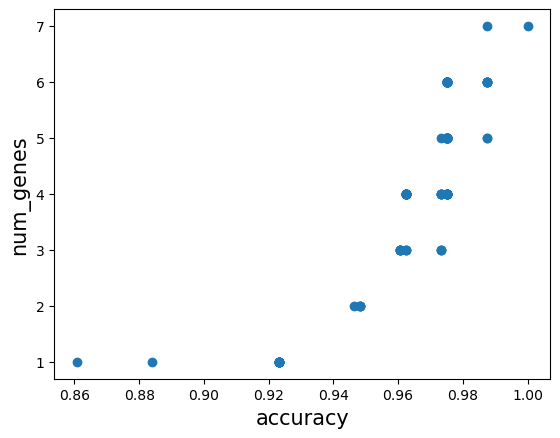

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  ['D31765_at' 'D83920_at' 'HG3313-HT3490_at' 'D14689_at' 'D79987_at'
 'AF000545_at' 'HG3995-HT4265_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  10
the best one of generation 2 is: accuracy is  0.95 , num of genes is  10
the best one of generation 3 is: accuracy is  0.95 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  9
the best one of generation 5 is: accuracy is  0.975 , num of genes is  8
the best one of generation 6 is: accuracy is  0.975 , num of genes is  8
the best one of generation 7 is: accuracy is  0.975 , num of genes is  8
the best one of generation 8 is: accuracy is  0.975 , num of genes is  8
the best one of generation 9 is: accuracy is  0.975 , num of genes is  4
the best one of generation 10 is: accuracy is  0.975 , num of ge

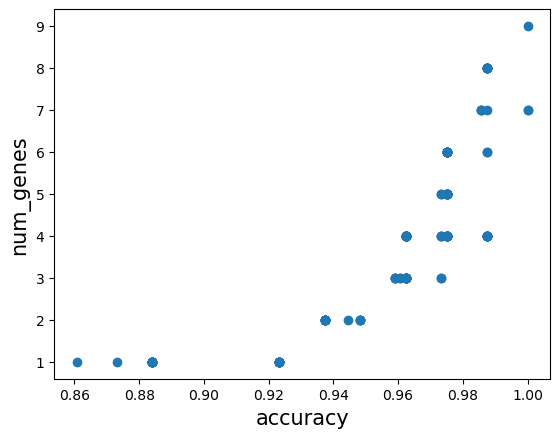

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  ['AF007551_at' 'D87433_at' 'D80005_at' 'AF002700_at' 'D86984_at'
 'D21255_at' 'HG1733-HT1748_at']
the best one of generation 0 is: accuracy is  0.95 , num of genes is  10
the best one of generation 1 is: accuracy is  0.95 , num of genes is  10
the best one of generation 2 is: accuracy is  0.95 , num of genes is  10
the best one of generation 3 is: accuracy is  0.975 , num of genes is  10
the best one of generation 4 is: accuracy is  0.975 , num of genes is  10
the best one of generation 5 is: accuracy is  0.975 , num of genes is  10
the best one of generation 6 is: accuracy is  0.975 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  9
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  9
the best one of

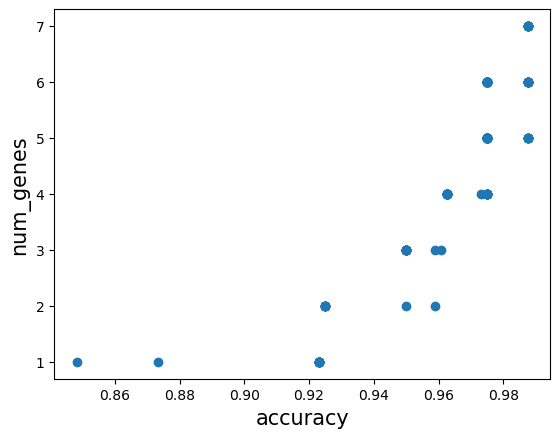

the best one is: accuracy is  0.9875 , num of genes is  5
selected genes are:  ['D10995_at' 'D14658_at' 'HG3432-HT3618_at' 'AB002365_at' 'AF000560_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 8 is: accuracy is  0.975 , num of genes is  6
the best one of generation 9 is: accuracy is  0.975 , num of genes is  6
the best one of generation 10 is: accuracy is  0.975 , num of genes is  6
the best one

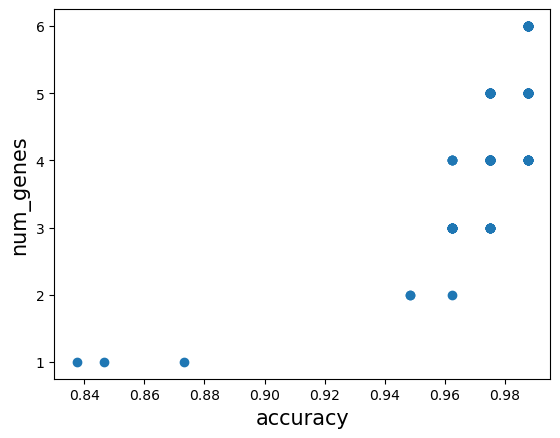

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D21163_at' 'AF005037_at' 'AF000560_at' 'D78275_at']
the best one of generation 0 is: accuracy is  0.9482142857142858 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9482142857142858 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9482142857142858 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 7 is: accuracy is  0.975 , num of genes is  9
the best one of generation 8 is: accuracy is  0.975 , num of genes is  9
the best one of generation 9 is: accuracy is  0.975 , num of genes is  9
the best one of generation 10 is: accuracy is  0.975 , num of genes is  9
the best one of g

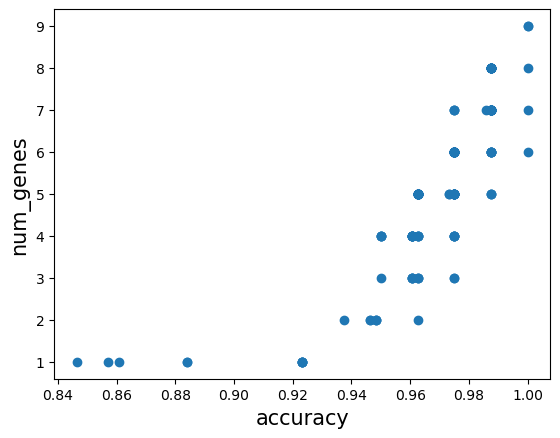

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['D87447_at' 'D76435_at' 'AF001294_at' 'D28124_at' 'D29677_at' 'D12625_at']
the best one of generation 0 is: accuracy is  0.9482142857142858 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9482142857142858 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9482142857142858 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9607142857142857 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  10
the best one of generation 10 is: a

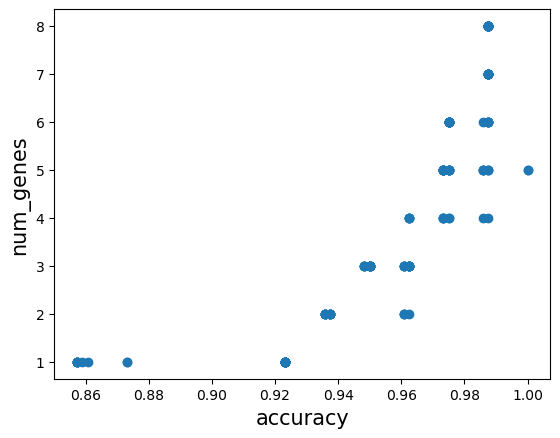

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['D12676_at' 'D11139_at' 'D31765_at' 'HG3995-HT4265_at' 'D87446_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  6
the best one of generation 1 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 6 is: accuracy is  0.975 , num of genes is  6
the best one of generation 7 is: accuracy is  0.975 , num of genes is  6
the best one of generation 8 is: accuracy is  0.975 , num of genes is  5
the best one of generation 9 is: accuracy is  0.975 , num of genes is  5
the best one of generation 10 is: accuracy is  

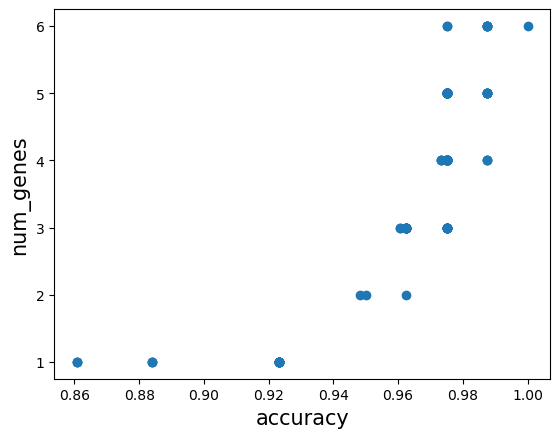

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['D28416_at' 'D26561_cds3_at' 'D80006_at' 'HG3995-HT4265_at' 'D87452_at'
 'D16815_at']
the best one of generation 0 is: accuracy is  0.9214285714285715 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 7 is: accuracy is  0.975 , num of genes is  6
the best one of generation 8 is: accuracy is  0.975 , num of genes is  6
the best one of generation 9 is: accuracy is  0.975 , num of genes is  6
the best one of generation 10 is: accuracy is  0.975 , num of genes is  6
th

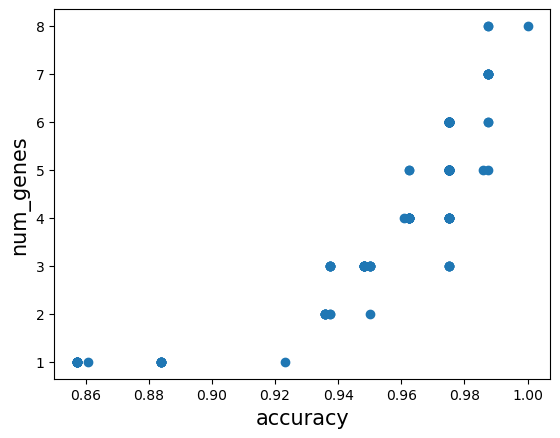

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  ['D13628_at' 'D79995_at' 'HG3313-HT3490_at' 'D87433_at' 'D87127_at'
 'D85418_at' 'AF005775_at' 'D88152_at']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  6
the best one of generation 1 is: accuracy is  0.9107142857142858 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9339285714285713 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9339285714285713 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 7 is: accuracy is  0.975 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  5
the best one of generation 10 is: accuracy i

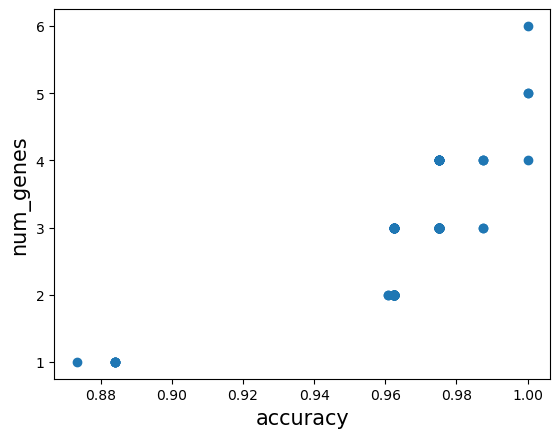

the best one is: accuracy is  1.0 , num of genes is  4
selected genes are:  ['D14658_at' 'D38293_at' 'D87433_at' 'AF005037_at']
the best one of generation 0 is: accuracy is  0.925 , num of genes is  7
the best one of generation 1 is: accuracy is  0.925 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  10
the best one of generation 5 is: accuracy is  0.975 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  6
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  6
the best one of generation 11 is: accuracy is  0.9875 , nu

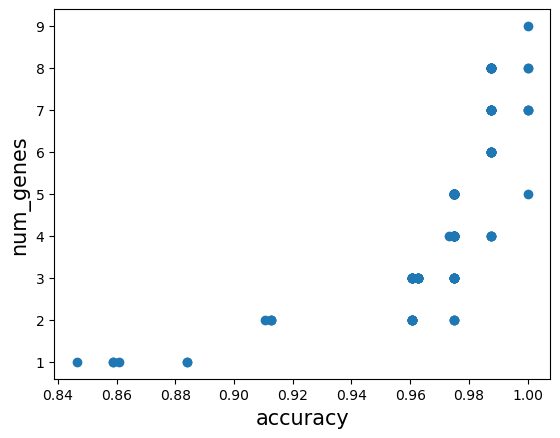

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['D79999_at' 'AF007551_at' 'D21255_at' 'D13637_at' 'D14874_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 4 is: accuracy is  0.975 , num of genes is  4
the best one of generation 5 is: accuracy is  0.975 , num of genes is  4
the best one of generation 6 is: accuracy is  0.975 , num of genes is  4
the best one of generation 7 is: accuracy is  0.975 , num of genes is  4
the best one of generation 8 is: accuracy is  0.975 , num of genes is  4
the best one of generation 9 is: accuracy is  0.975 , num of genes is  4
the best one of generation 10 is: accuracy is  0.975 , num of genes is  4
the best one of generation 1

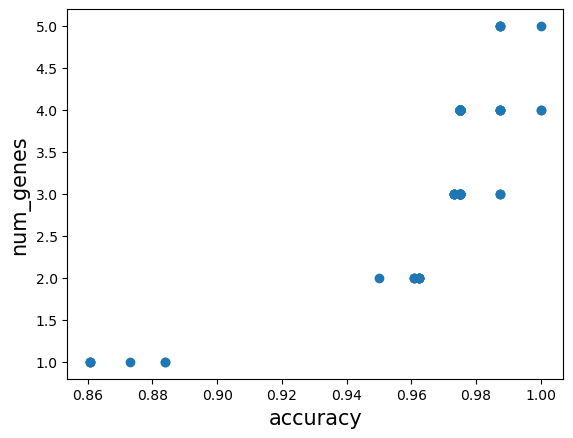

the best one is: accuracy is  1.0 , num of genes is  4
selected genes are:  ['D63478_at' 'AF001294_at' 'D11086_at' 'D87447_at']
the best one of generation 0 is: accuracy is  0.95 , num of genes is  10
the best one of generation 1 is: accuracy is  0.95 , num of genes is  10
the best one of generation 2 is: accuracy is  0.95 , num of genes is  10
the best one of generation 3 is: accuracy is  0.95 , num of genes is  10
the best one of generation 4 is: accuracy is  0.95 , num of genes is  6
the best one of generation 5 is: accuracy is  0.95 , num of genes is  6
the best one of generation 6 is: accuracy is  0.95 , num of genes is  6
the best one of generation 7 is: accuracy is  0.95 , num of genes is  6
the best one of generation 8 is: accuracy is  0.95 , num of genes is  6
the best one of generation 9 is: accuracy is  0.95 , num of genes is  6
the best one of generation 10 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 11 is: accuracy is  0.9625 , num o

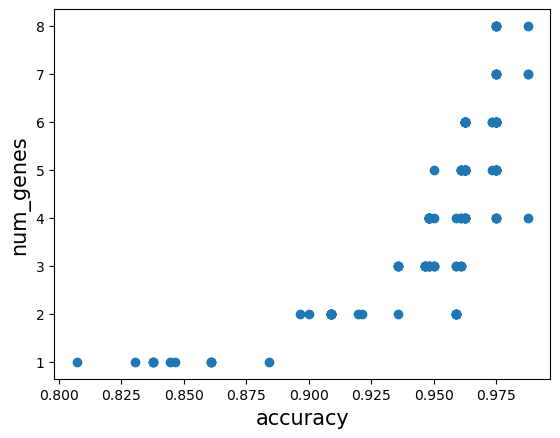

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D29641_at' 'AF007551_at' 'D80006_at' 'AF005037_at']
the best one of generation 0 is: accuracy is  0.9482142857142858 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9482142857142858 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 7 is: accuracy is  0.975 , num of genes is  8
the best one of generation 8 is: accuracy is  0.975 , num of genes is  7
the best one of generation 9 is: accuracy is  0.975 , num of genes is  7
the best one of generation 10 is: accuracy is  0.975 , num of genes is  7
the best one of generation 11 

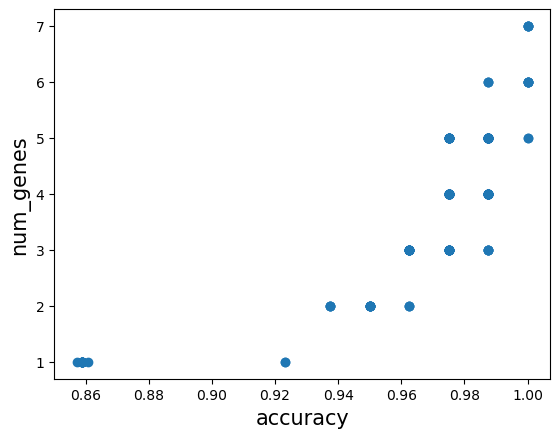

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['AD000092_cds2_at' 'D43948_at' 'AC000064_cds1_at' 'AF000560_at'
 'D49493_at']
the best one of generation 0 is: accuracy is  0.925 , num of genes is  6
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  6
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 7 is: accuracy is  0.975 , num of genes is  7
the best one of generation 8 is: accuracy is  0.975 , num of genes is  7
the best one of generation 9 is: accuracy is  0.975 , num of genes is  7
the best one of generation 10 is: accuracy is  0.975 , num of genes is  7
the best one of generation 11 is: a

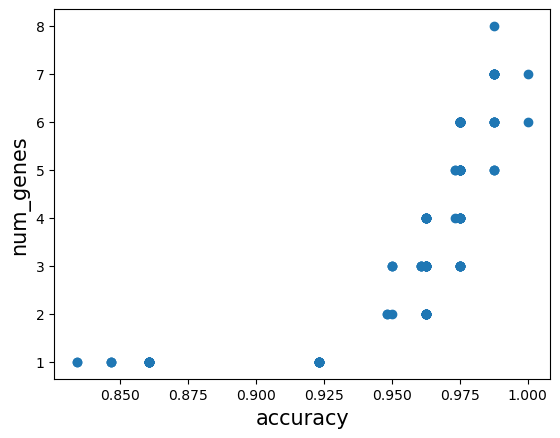

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['D83776_at' 'AF015950_at' 'D31883_at' 'D43948_at' 'D25539_at' 'D29810_at']
the best one of generation 0 is: accuracy is  0.925 , num of genes is  6
the best one of generation 1 is: accuracy is  0.925 , num of genes is  6
the best one of generation 2 is: accuracy is  0.925 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 9 is: accuracy is  0.975 , num of genes is  8
the best one of generation 10 is: accuracy is  0.975

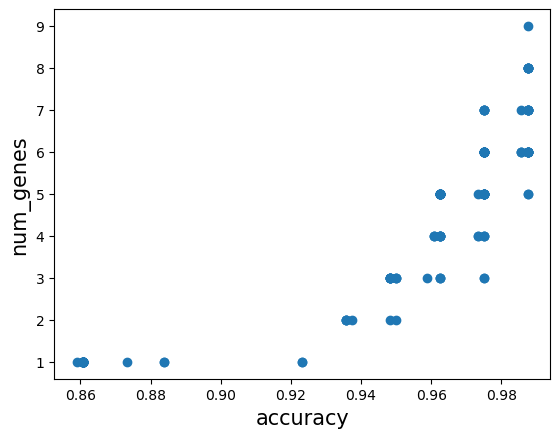

the best one is: accuracy is  0.9875 , num of genes is  5
selected genes are:  ['D43948_at' 'D16562_at' 'D42063_at' 'D63485_at' 'D44466_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 4 is: accuracy is  0.95 , num of genes is  8
the best one of generation 5 is: accuracy is  0.95 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 10 is: accuracy is  0.975 , num of genes is  6
the best one of generation 11 is: accuracy is  0.

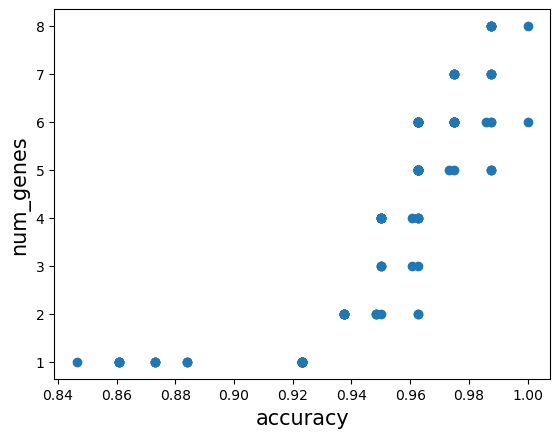

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['AB002409_at' 'AF007551_at' 'D14694_at' 'D87447_at' 'D12763_at'
 'AB000449_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9482142857142858 , num of genes is  6
the best one of generation 4 is: accuracy is  0.95 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9732142857142858 , num of genes is  6
the best one of generation 10 is: accuracy is  0.9875 , num of genes

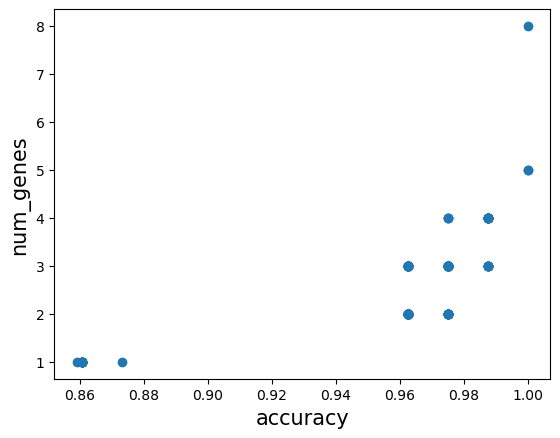

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['HG2152-HT2222_at' 'D76435_at' 'HG3566-HT3769_at' 'AF001294_at'
 'D23673_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 8 is: accuracy is  0.975 , num of genes is  5
the best one of generation 9 is: accuracy is  0.975 , num of genes is  5
the best one of generation 10 is: accuracy is  0.975 , num of genes is  5
the best one of generation 11 is:

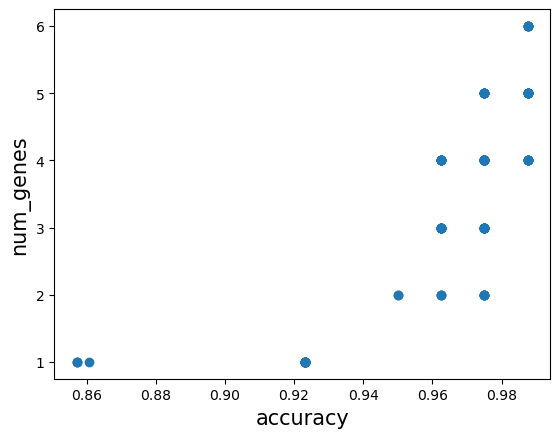

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['AF005037_at' 'D79999_at' 'D50857_at' 'AD000092_cds2_at']
the best one of generation 0 is: accuracy is  0.9232142857142858 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 6 is: accuracy is  0.975 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  3
the best one of generation 11 is: a

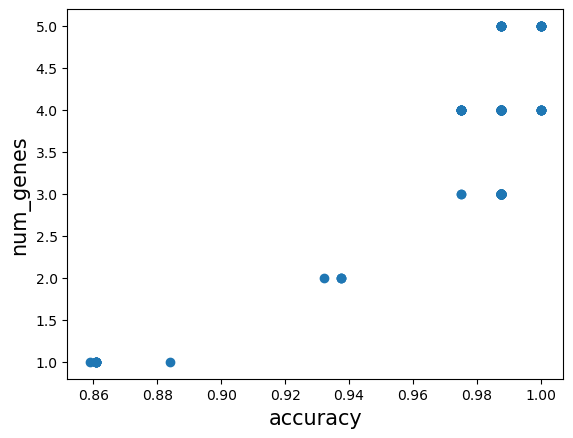

the best one is: accuracy is  1.0 , num of genes is  4
selected genes are:  ['D14658_at' 'D30758_at' 'D16562_at' 'HG3995-HT4265_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9482142857142858 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9482142857142858 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9482142857142858 , num of genes is  4
the best one of generation 4 is: accuracy is  0.95 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 7 is: accuracy is  0.975 , num of genes is  7
the best one of generation 8 is: accuracy is  0.975 , num of genes is  7
the best one of generation 9 is: accuracy is  0.975 , num of genes is  7
the best one of generation 10 is: accuracy is  0.975 , num of genes is  4
the best one of gener

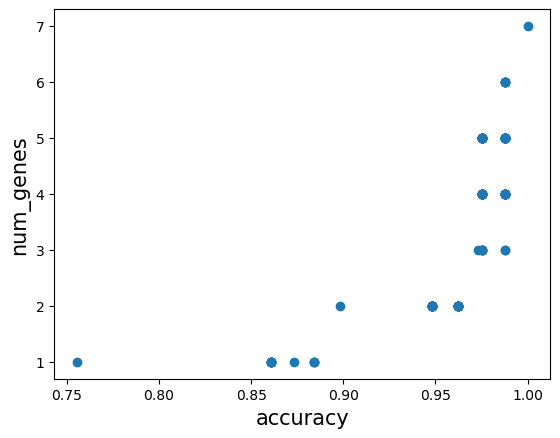

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  ['D87463_at' 'D12625_at' 'D16562_at' 'D26561_cds3_at' 'D17357_at'
 'AC002115_rna2_at' 'D12686_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 7 is: accuracy is  0.975 , num of genes is  8
the best one of generation 8 is: accuracy is  0.975 , num of genes is  8
the best one of generation 9 is: accuracy is  0.975 , num of genes is  7
the best one of generation 10 is: accuracy is  0.975 , num of ge

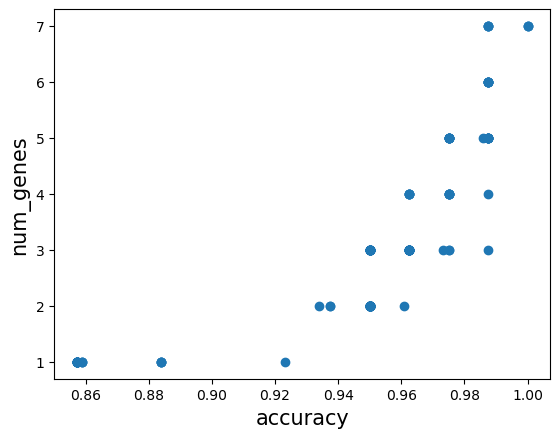

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  ['HG2161-HT2231_at' 'D38521_at' 'HG2709-HT2805_at' 'D14874_at' 'D17400_at'
 'D14658_at' 'D38550_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9357142857142857 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 5 is: accuracy is  0.95 , num of genes is  10
the best one of generation 6 is: accuracy is  0.95 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 10 is: accuracy is  0.9

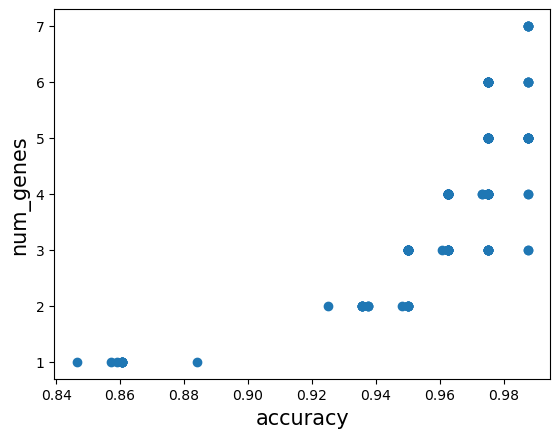

the best one is: accuracy is  0.9875 , num of genes is  3
selected genes are:  ['HG3995-HT4265_at' 'D79987_at' 'D30758_at']
the best one of generation 0 is: accuracy is  0.95 , num of genes is  7
the best one of generation 1 is: accuracy is  0.95 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 3 is: accuracy is  0.975 , num of genes is  7
the best one of generation 4 is: accuracy is  0.975 , num of genes is  7
the best one of generation 5 is: accuracy is  0.975 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9875 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  4
the best one of generation 11 is: accuracy is  0.9875 , num of genes

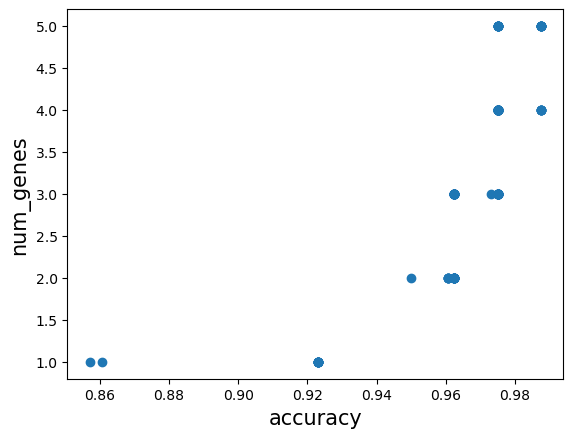

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D42123_at' 'D79987_at' 'D23673_at' 'AF001294_at']
the best one of generation 0 is: accuracy is  0.9232142857142858 , num of genes is  7
the best one of generation 1 is: accuracy is  0.925 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  7
the best one of generation 4 is: accuracy is  0.95 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 8 is: accuracy is  0.975 , num of genes is  5
the best one of generation 9 is: accuracy is  0.975 , num of genes is  5
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  5
the best one of generation 11 is: accuracy is  

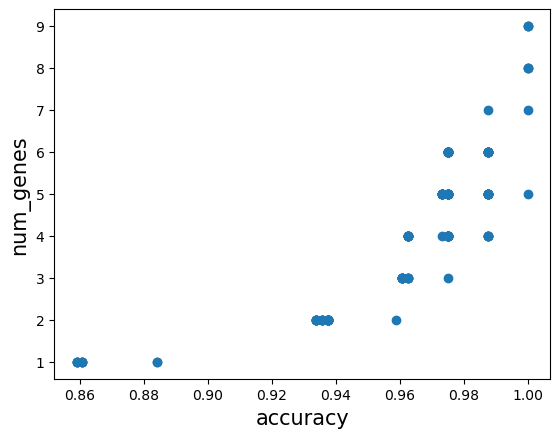

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['D85418_at' 'D87433_at' 'D29833_at' 'D80011_at' 'D15050_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 2 is: accuracy is  0.95 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 10 is: accuracy is  0.9625 , num of g

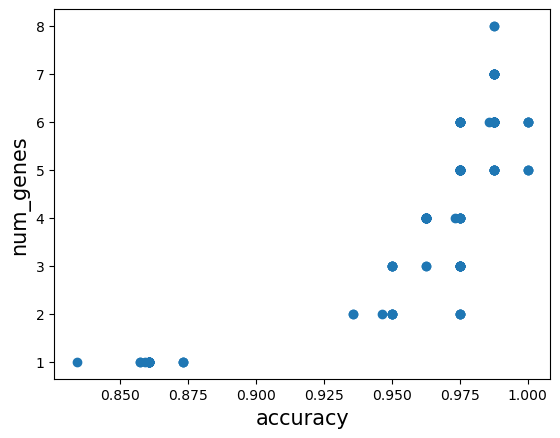

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['D86976_at' 'D84307_at' 'D76435_at' 'D12763_at' 'D30037_at']


In [10]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
#df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=10,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1

the best one of generation 0 is: accuracy is  0.925 , num of genes is  6
the best one of generation 1 is: accuracy is  0.925 , num of genes is  6
the best one of generation 2 is: accuracy is  0.9357142857142857 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9482142857142858 , num of genes is  14
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  6
the best one of generation 5 is: accuracy is  0.975 , num of genes is  7
the best one of generation 6 is: accuracy is  0.975 , num of genes is  7
the best one of generation 7 is: accuracy is  0.975 , num of genes is  6
the best one of generation 8 is: accuracy is  0.975 , num of genes is  6
the best one of generation 9 is: accuracy is  0.975 , num of genes is  5
the best one of generation 10 is: accuracy is  0.975 , num of genes is  5
the best one of generation 11 is: accuracy is  0.975 , num of genes is  5
the best one of generation 12 is: accuracy is  0.9875 , num of genes is  7
the best one of gen

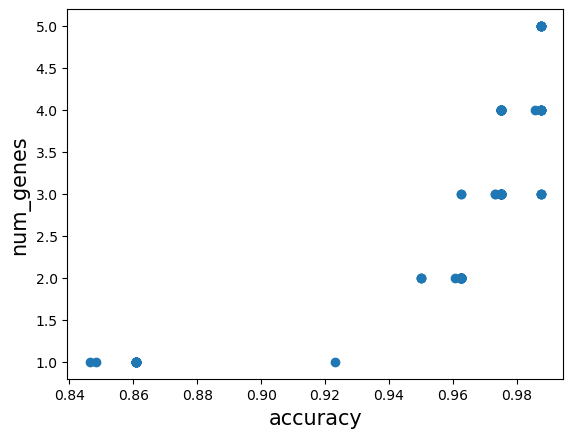

the best one is: accuracy is  0.9875 , num of genes is  3
selected genes are:  ['AF005037_at' 'D83243_at' 'AF000560_at']
the best one of generation 0 is: accuracy is  0.95 , num of genes is  13
the best one of generation 1 is: accuracy is  0.95 , num of genes is  13
the best one of generation 2 is: accuracy is  0.95 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  10
the best one of generation 5 is: accuracy is  0.975 , num of genes is  12
the best one of generation 6 is: accuracy is  0.975 , num of genes is  10
the best one of generation 7 is: accuracy is  0.975 , num of genes is  10
the best one of generation 8 is: accuracy is  0.975 , num of genes is  10
the best one of generation 9 is: accuracy is  0.975 , num of genes is  7
the best one of generation 10 is: accuracy is  0.975 , num of genes is  7
the best one of generation 11 is: accuracy is  0.975 , 

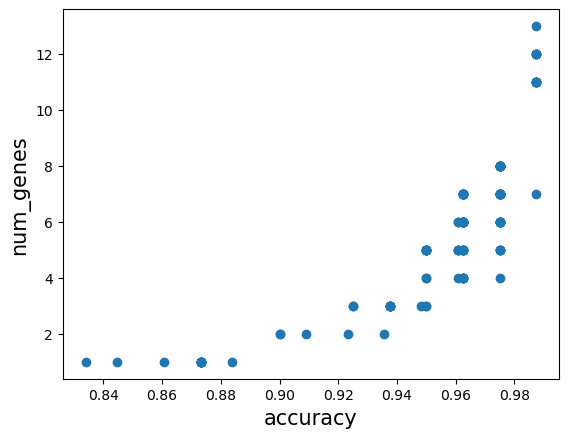

the best one is: accuracy is  0.9875 , num of genes is  7
selected genes are:  ['D38076_at' 'HG25930-HT26386_at' 'D38550_at' 'D11428_at'
 'HG172-HT3924_at' 'D87444_at' 'D83243_at']
the best one of generation 0 is: accuracy is  0.925 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9607142857142857 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  12
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  12
the best one of generation 5 is: accuracy is  0.9607142857142857 , num of genes is  12
the best one of generation 6 is: accuracy is  0.9607142857142857 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9732142857142858 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9732142857142858 , num of genes is  4
the best one of generation 9 is: accuracy is  0.975 , num of genes

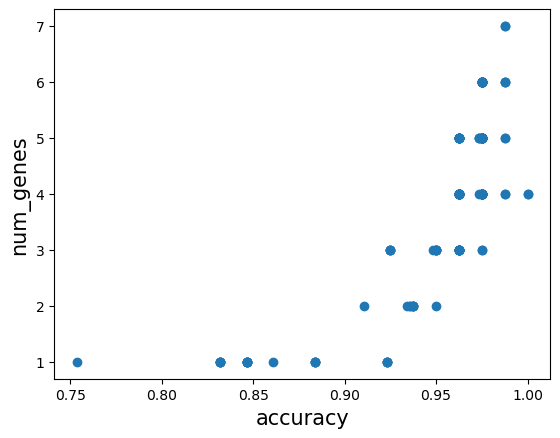

the best one is: accuracy is  1.0 , num of genes is  4
selected genes are:  ['D87442_at' 'D29677_at' 'D63485_at' 'D12763_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  11
the best one of generation 3 is: accuracy is  0.975 , num of genes is  6
the best one of generation 4 is: accuracy is  0.975 , num of genes is  6
the best one of generation 5 is: accuracy is  0.975 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9857142857142858 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  7
the best one of generation 10 is: accuracy is  1.0 , num of genes is  7
the best one of generation 11 is: accu

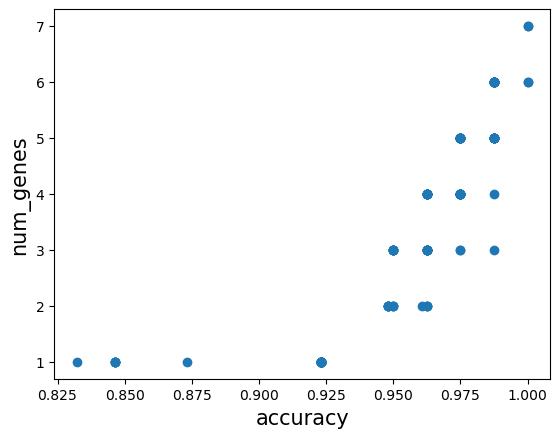

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['AD000092_cds2_at' 'AF002224_at' 'D86980_at' 'D10995_at' 'D87458_at'
 'D80005_at']
the best one of generation 0 is: accuracy is  0.95 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  12
the best one of generation 5 is: accuracy is  0.975 , num of genes is  14
the best one of generation 6 is: accuracy is  0.975 , num of genes is  12
the best one of generation 7 is: accuracy is  0.975 , num of genes is  12
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  14
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  11
the best one of gen

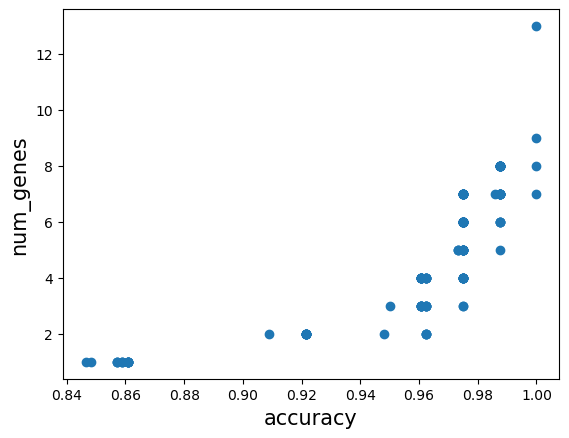

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  ['D86956_at' 'AF009426_at' 'D17400_at' 'HG2274-HT2370_at' 'D26443_at'
 'AC002115_cds3_at' 'D80006_at']
the best one of generation 0 is: accuracy is  0.9482142857142858 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9482142857142858 , num of genes is  13
the best one of generation 2 is: accuracy is  0.95 , num of genes is  9
the best one of generation 3 is: accuracy is  0.95 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 5 is: accuracy is  0.975 , num of genes is  9
the best one of generation 6 is: accuracy is  0.975 , num of genes is  8
the best one of generation 7 is: accuracy is  0.975 , num of genes is  8
the best one of generation 8 is: accuracy is  0.975 , num of genes is  3
the best one of generation 9 is: accuracy is  0.975 , num of genes is  3
the best one of generation 10 is: accuracy is  0.975 , num of g

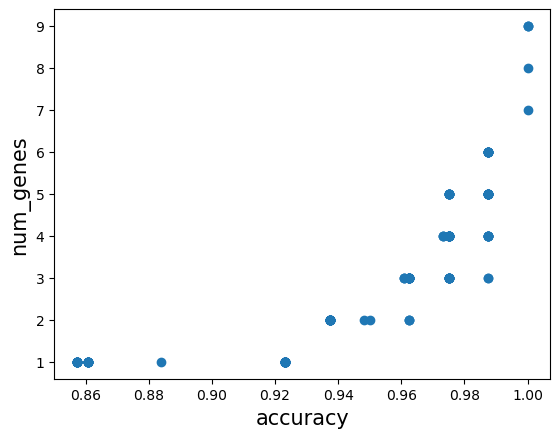

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  ['D13897_rna2_at' 'D21853_at' 'HG3063-HT3224_at' 'AF001294_at' 'D86965_at'
 'D86962_at' 'D49394_at']
the best one of generation 0 is: accuracy is  0.975 , num of genes is  14
the best one of generation 1 is: accuracy is  0.975 , num of genes is  14
the best one of generation 2 is: accuracy is  0.975 , num of genes is  14
the best one of generation 3 is: accuracy is  0.975 , num of genes is  14
the best one of generation 4 is: accuracy is  0.975 , num of genes is  14
the best one of generation 5 is: accuracy is  0.975 , num of genes is  3
the best one of generation 6 is: accuracy is  0.975 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  4
the best o

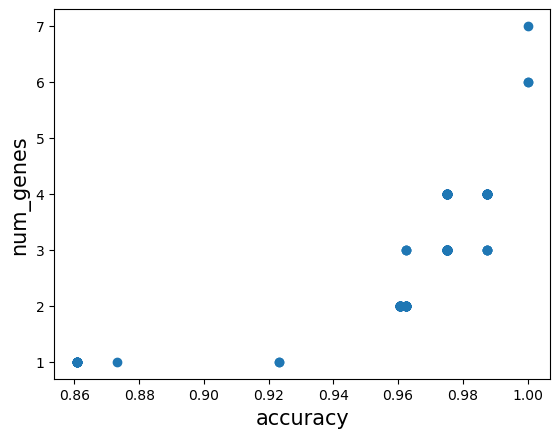

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['D15050_at' 'HG3994-HT4264_at' 'D79987_at' 'D11139_at' 'D86980_at'
 'AC002115_cds4_at']
the best one of generation 0 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 4 is: accuracy is  0.975 , num of genes is  6
the best one of generation 5 is: accuracy is  0.975 , num of genes is  6
the best one of generation 6 is: accuracy is  0.975 , num of genes is  6
the best one of generation 7 is: accuracy is  0.975 , num of genes is  6
the best one of generation 8 is: accuracy is  0.975 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  8
the best one of generatio

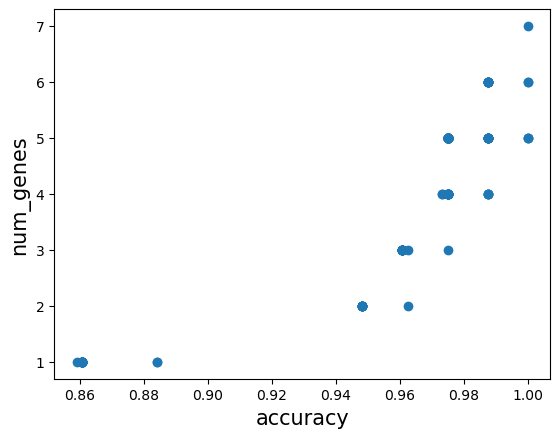

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['D14694_at' 'D42085_at' 'AF001294_at' 'D79985_at' 'D26443_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  12
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  12
the best one of generation 2 is: accuracy is  0.9482142857142858 , num of genes is  13
the best one of generation 3 is: accuracy is  0.95 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  11
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 6 is: accuracy is  0.975 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  12
the best one o

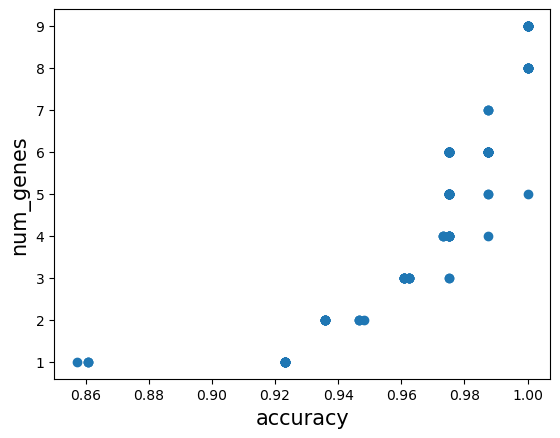

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['D11086_at' 'AF001294_at' 'D76435_at' 'AB002380_at' 'D42108_at']
the best one of generation 0 is: accuracy is  0.95 , num of genes is  10
the best one of generation 1 is: accuracy is  0.95 , num of genes is  7
the best one of generation 2 is: accuracy is  0.95 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9589285714285714 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9732142857142858 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9732142857142858 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9732142857142858 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9732142857142858 , num of genes is  10
the best one of generation 8 is: accuracy is  0.975 , num of genes is  7
the best one of generation 9 is: accuracy is  0.975 , num of genes is  7
the best one of generation 10 is: accuracy is  0.975 , num o

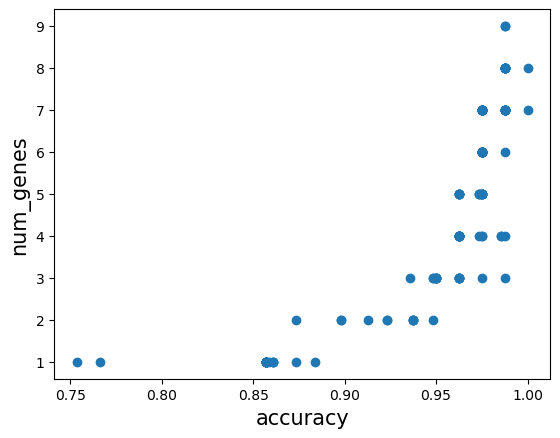

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  ['D86962_at' 'AF005037_at' 'D16294_at' 'AC002115_rna2_at' 'D42085_at'
 'D87433_at' 'AF002224_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9482142857142858 , num of genes is  7
the best one of generation 3 is: accuracy is  0.95 , num of genes is  15
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  12
the best one of generation 8 is: accuracy is  0.975 , num of genes is  8
the best one of generation 9 is: accuracy is  0.975 , num of genes is  8
the best one of generation 10 is: accuracy is  0.975 , num of genes is 

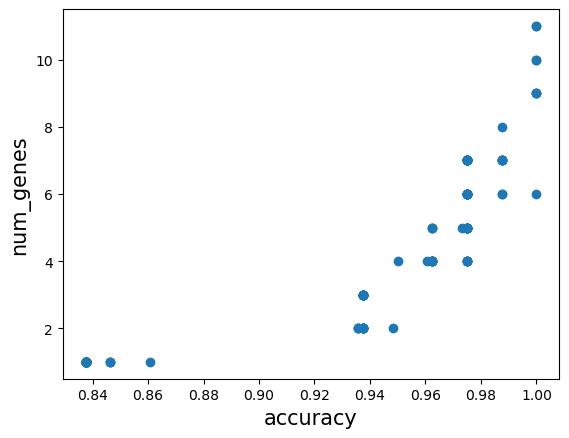

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['D87442_at' 'D26561_cds2_at' 'D87452_at' 'D63486_at' 'AF000231_at'
 'D21853_at']
the best one of generation 0 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 2 is: accuracy is  0.975 , num of genes is  9
the best one of generation 3 is: accuracy is  0.975 , num of genes is  9
the best one of generation 4 is: accuracy is  0.975 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9875 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  8
the best one of generation 11

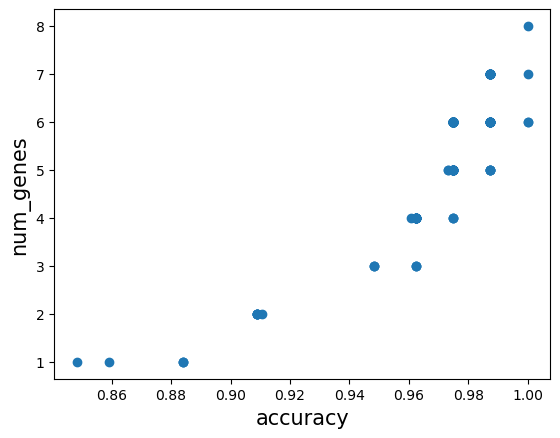

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['HG25930-HT26386_at' 'HG2992-HT5186_at' 'D83004_at' 'HG3893-HT4163_at'
 'AB000897_at' 'D26443_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  11
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  10
the best one of generation 2 is: accuracy is  0.95 , num of genes is  15
the best one of generation 3 is: accuracy is  0.95 , num of genes is  15
the best one of generation 4 is: accuracy is  0.95 , num of genes is  15
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  7
the best one of generation 10 is: accuracy is  0.975 , num of genes is  8
the best 

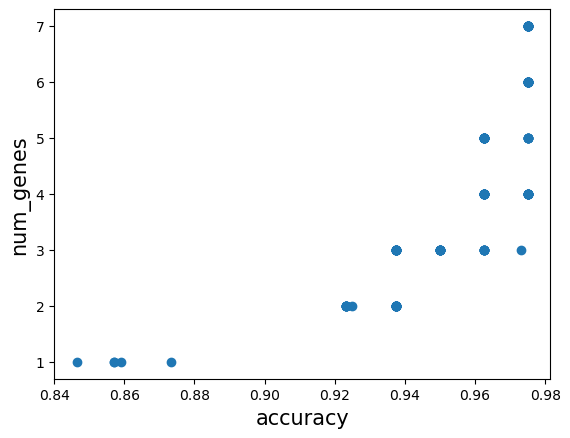

the best one is: accuracy is  0.975 , num of genes is  4
selected genes are:  ['AB000896_at' 'D11086_at' 'D87442_at' 'D12625_at']
the best one of generation 0 is: accuracy is  0.925 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  12
the best one of generation 3 is: accuracy is  0.95 , num of genes is  15
the best one of generation 4 is: accuracy is  0.95 , num of genes is  15
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  15
the best one of generation 6 is: accuracy is  0.975 , num of genes is  15
the best one of generation 7 is: accuracy is  0.975 , num of genes is  14
the best one of generation 8 is: accuracy is  0.975 , num of genes is  14
the best one of generation 9 is: accuracy is  0.975 , num of genes is  13
the best one of generation 10 is: accuracy is  0.975 , num of genes is  13
the best one of generation 11 is: accuracy is  0.975 ,

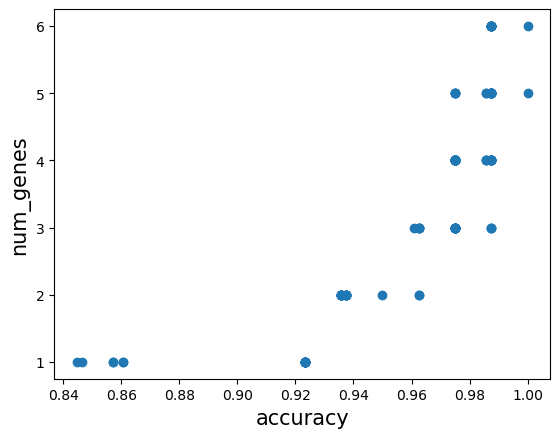

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['D80011_at' 'D29963_at' 'D14533_at' 'D87433_at' 'D21255_at']
the best one of generation 0 is: accuracy is  0.95 , num of genes is  13
the best one of generation 1 is: accuracy is  0.95 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9607142857142857 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9875 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 9 is: accuracy is  1.0 , num of genes is  13
the best one of generation 10 is: accuracy is  1.0 , num of genes is  13
the best o

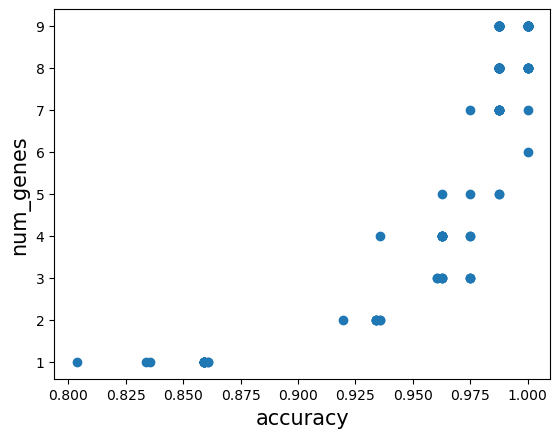

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['D86979_at' 'D83195_at' 'D50917_at' 'HG3454-HT3647_at' 'AF001294_at'
 'D26561_cds2_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  12
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  12
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 6 is: accuracy is  0.975 , num of genes is  11
the best one of generation 7 is: accuracy is  0.975 , num of genes is  11
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  12
the best one of generation 10 is: accuracy is  0.9875 , num of gen

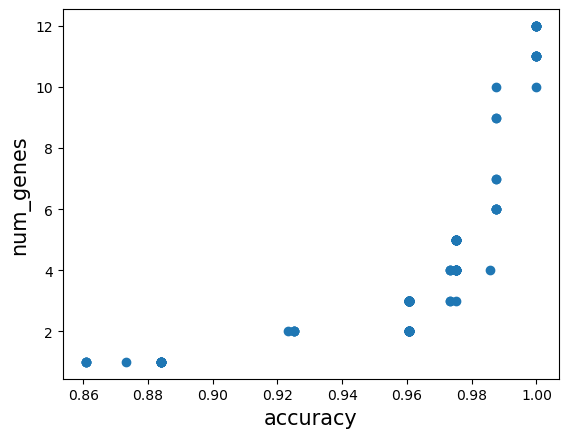

the best one is: accuracy is  1.0 , num of genes is  10
selected genes are:  ['D16227_at' 'H46990_at' 'D14694_at' 'D23662_at' 'D21337_at' 'D38524_at'
 'D28124_at' 'AB004884_at' 'HG2228-HT2305_at' 'D87442_at']
the best one of generation 0 is: accuracy is  0.925 , num of genes is  12
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  8
the best one of generation 8 is: accuracy is  0.975 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  10
the best one

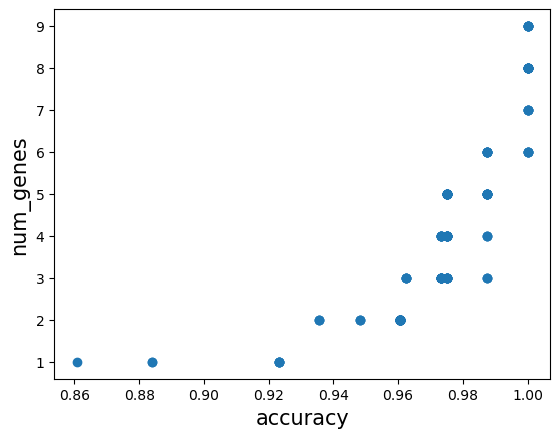

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['HG3231-HT3408_at' 'AF007551_at' 'D21163_at' 'D13633_at' 'D87452_at'
 'HG3313-HT3490_at']
the best one of generation 0 is: accuracy is  0.9339285714285716 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9339285714285716 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9482142857142858 , num of genes is  9
the best one of generation 3 is: accuracy is  0.95 , num of genes is  14
the best one of generation 4 is: accuracy is  0.95 , num of genes is  14
the best one of generation 5 is: accuracy is  0.95 , num of genes is  13
the best one of generation 6 is: accuracy is  0.95 , num of genes is  5
the best one of generation 7 is: accuracy is  0.95 , num of genes is  5
the best one of generation 8 is: accuracy is  0.975 , num of genes is  5
the best one of generation 9 is: accuracy is  0.975 , num of genes is  5
the best one of generation 10 is: accuracy is  0.975 , num of gene

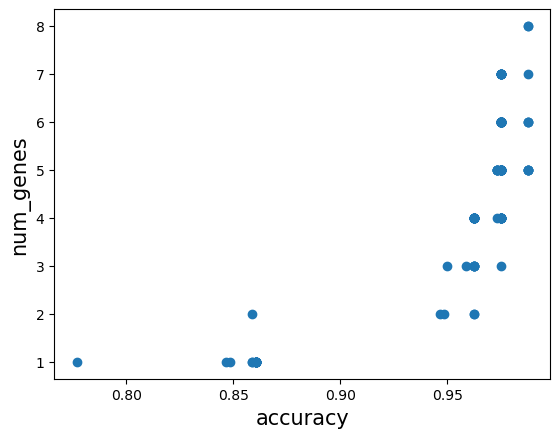

the best one is: accuracy is  0.9875 , num of genes is  5
selected genes are:  ['D78611_at' 'D28137_at' 'D78261_at' 'AF001294_at' 'D49400_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9607142857142857 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 9 is: accuracy is  0.975 , num of genes is  12
the best one of generation 10 is: accuracy is  0.975 , num of genes is  3
the best one of g

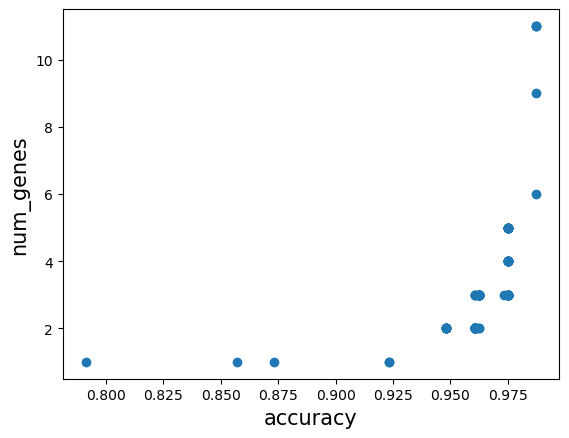

the best one is: accuracy is  0.9875 , num of genes is  6
selected genes are:  ['AF005037_at' 'AC000064_cds1_at' 'AC002464_at' 'HG2161-HT2231_at'
 'D32202_at' 'D14533_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9357142857142857 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 4 is: accuracy is  0.95 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9875 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  3
the best one of generation 10 is: accuracy is  0.98

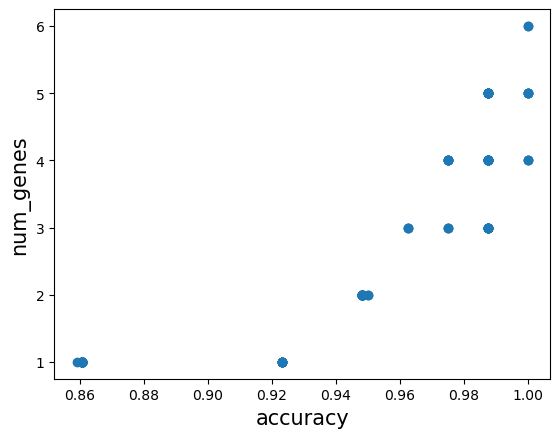

the best one is: accuracy is  1.0 , num of genes is  4
selected genes are:  ['D83243_at' 'D15050_at' 'D87447_at' 'D28476_at']
the best one of generation 0 is: accuracy is  0.9232142857142858 , num of genes is  13
the best one of generation 1 is: accuracy is  0.925 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9357142857142857 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9375 , num of genes is  9
the best one of generation 5 is: accuracy is  0.95 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  13
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  12
the best one of generation 9 is: accuracy is  0.975 , num of genes is  6
the best one of generation 10 is: accuracy is  0.975 , num of genes is  6
the best one of generation 11 is:

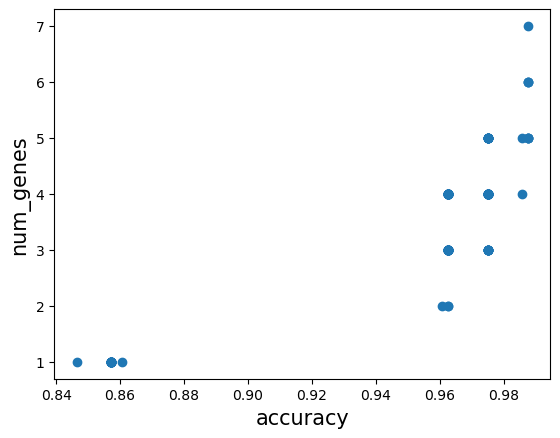

the best one is: accuracy is  0.9875 , num of genes is  5
selected genes are:  ['HG1098-HT1098_at' 'HG3432-HT3618_at' 'D79987_at' 'D15050_at' 'D29963_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  14
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9482142857142858 , num of genes is  14
the best one of generation 5 is: accuracy is  0.95 , num of genes is  11
the best one of generation 6 is: accuracy is  0.95 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  14
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  10
the best one of generation 10 is: accuracy is  0.975 , num of genes is  11


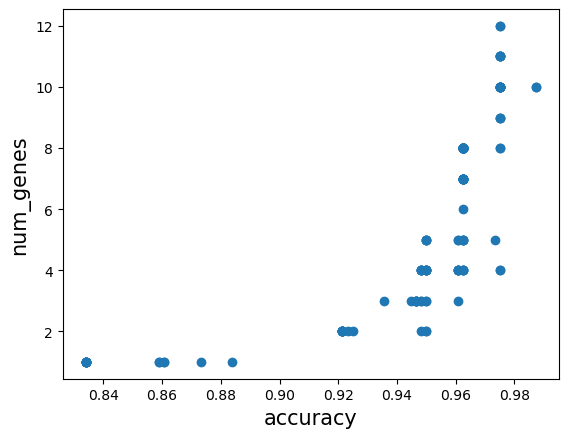

the best one is: accuracy is  0.9875 , num of genes is  10
selected genes are:  ['D43767_at' 'D12763_at' 'D76435_at' 'HG384-HT384_at' 'HG3400-HT3579_at'
 'D26135_at' 'AD001527_cds1_at' 'D38305_at' 'D50917_at' 'HG2663-HT2759_at']
the best one of generation 0 is: accuracy is  0.9482142857142858 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9482142857142858 , num of genes is  15
the best one of generation 2 is: accuracy is  0.95 , num of genes is  11
the best one of generation 3 is: accuracy is  0.95 , num of genes is  11
the best one of generation 4 is: accuracy is  0.9732142857142858 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9732142857142858 , num of genes is  7
the best one of generation 6 is: accuracy is  0.975 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9875 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9875 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9875 , nu

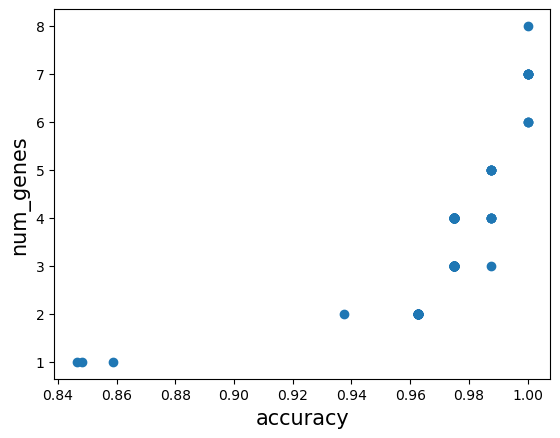

the best one is: accuracy is  1.0 , num of genes is  6
selected genes are:  ['AF001294_at' 'D86979_at' 'D17357_at' 'D21163_at' 'D38521_at' 'D26600_at']
the best one of generation 0 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  7
the best one of generation 4 is: accuracy is  0.975 , num of genes is  9
the best one of generation 5 is: accuracy is  0.975 , num of genes is  8
the best one of generation 6 is: accuracy is  0.975 , num of genes is  8
the best one of generation 7 is: accuracy is  0.975 , num of genes is  8
the best one of generation 8 is: accuracy is  0.975 , num of genes is  8
the best one of generation 9 is: accuracy is  0.975 , num of genes is  8
the best one of generation 10 is: accuracy is  0.975 , num of gene

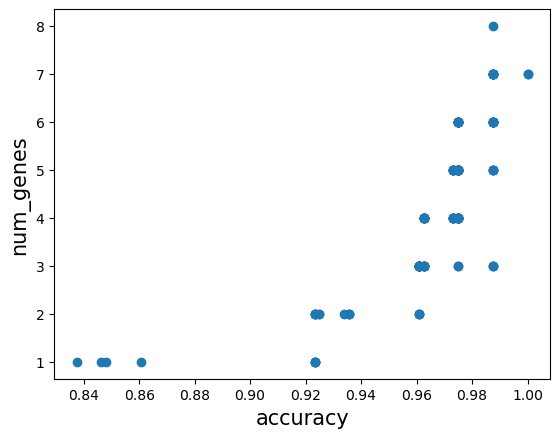

the best one is: accuracy is  1.0 , num of genes is  7
selected genes are:  ['D86963_at' 'D88532_at' 'AF007551_at' 'D23660_at' 'D83657_at' 'D13637_at'
 'D83702_at']
the best one of generation 0 is: accuracy is  0.95 , num of genes is  15
the best one of generation 1 is: accuracy is  0.95 , num of genes is  15
the best one of generation 2 is: accuracy is  0.95 , num of genes is  15
the best one of generation 3 is: accuracy is  0.975 , num of genes is  9
the best one of generation 4 is: accuracy is  0.975 , num of genes is  9
the best one of generation 5 is: accuracy is  0.975 , num of genes is  9
the best one of generation 6 is: accuracy is  0.975 , num of genes is  9
the best one of generation 7 is: accuracy is  0.975 , num of genes is  9
the best one of generation 8 is: accuracy is  0.975 , num of genes is  9
the best one of generation 9 is: accuracy is  0.975 , num of genes is  9
the best one of generation 10 is: accuracy is  0.975 , num of genes is  9
the best one of generation 11 i

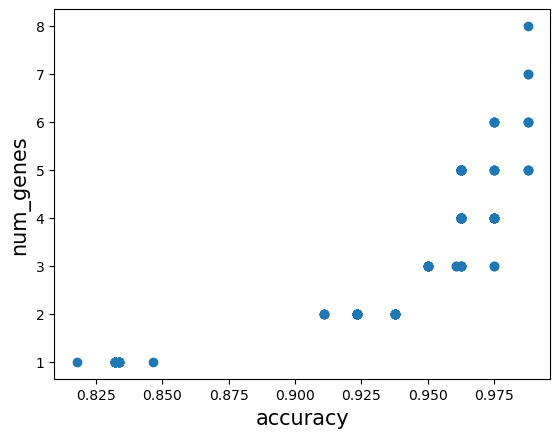

the best one is: accuracy is  0.9875 , num of genes is  5
selected genes are:  ['D90276_at' 'AF005037_at' 'D87442_at' 'D13628_at' 'AC002115_rna2_at']


In [7]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=15,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1

the best one of generation 0 is: accuracy is  0.9 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9107142857142858 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9232142857142858 , num of genes is  4
the best one of generation 3 is: accuracy is  0.95 , num of genes is  5
the best one of generation 4 is: accuracy is  0.95 , num of genes is  5
the best one of generation 5 is: accuracy is  0.95 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 10 is: accuracy is  0.975 , num of genes is  4
the best one of generation 11 is: accuracy is  0.975 , num of genes is  4
the best one of generation 12 is: accuracy is  0.975 , num of genes is  4
the best one of generat

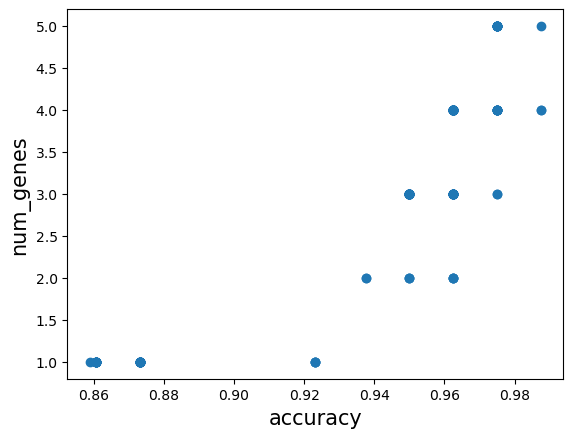

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D14874_at' 'D87442_at' 'D44466_at' 'D78334_at']
the best one of generation 0 is: accuracy is  0.8875 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8875 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9107142857142858 , num of genes is  3
the best one of generation 3 is: accuracy is  0.95 , num of genes is  3
the best one of generation 4 is: accuracy is  0.95 , num of genes is  3
the best one of generation 5 is: accuracy is  0.95 , num of genes is  3
the best one of generation 6 is: accuracy is  0.95 , num of genes is  3
the best one of generation 7 is: accuracy is  0.95 , num of genes is  3
the best one of generation 8 is: accuracy is  0.95 , num of genes is  3
the best one of generation 9 is: accuracy is  0.95 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9607142857142857 , num of genes is  3
the best one of generation 11 is: accuracy is 

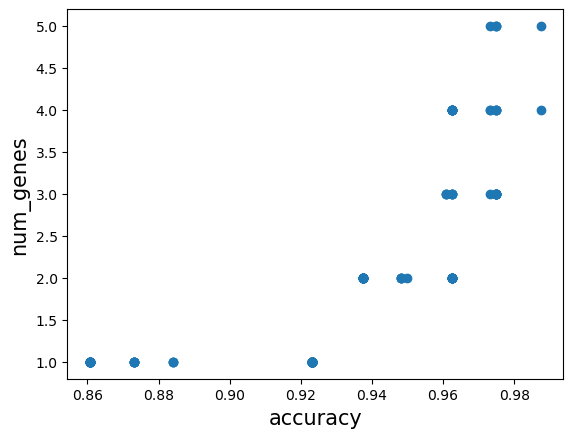

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D49817_at' 'D84361_at' 'D29677_at' 'D49493_at']
the best one of generation 0 is: accuracy is  0.8857142857142858 , num of genes is  3
the best one of generation 1 is: accuracy is  0.8982142857142857 , num of genes is  2
the best one of generation 2 is: accuracy is  0.8982142857142857 , num of genes is  2
the best one of generation 3 is: accuracy is  0.9107142857142858 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 9 is: accuracy is  0.95 , num of genes is  5
the best one of generatio

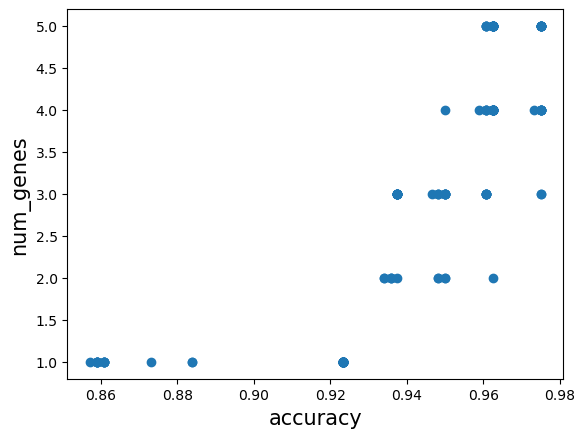

the best one is: accuracy is  0.975 , num of genes is  3
selected genes are:  ['HG2573-HT2669_at' 'AF000560_at' 'D14874_at']
the best one of generation 0 is: accuracy is  0.8964285714285716 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8964285714285716 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9089285714285715 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9107142857142858 , num of genes is  5
the best one of generation 4 is: accuracy is  0.925 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9357142857142857 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9357142857142857 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9375 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 10 is: accuracy is  0.9625 , num of g

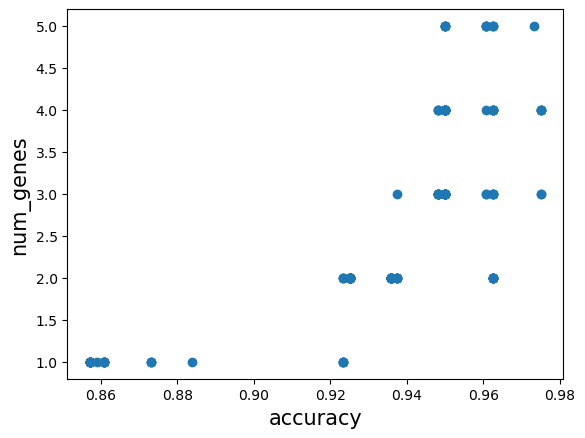

the best one is: accuracy is  0.975 , num of genes is  3
selected genes are:  ['AF007551_at' 'D89858_at' 'HG2723-HT2819_at']
the best one of generation 0 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 5 is: accuracy is  0.975 , num of genes is  4
the best one of generation 6 is: accuracy is  0.975 , num of genes is  4
the best one of generation 7 is: accuracy is  0.975 , num of genes is  4
the best one of generation 8 is: accuracy is  0.975 , num of genes is  4
the best one of generation 9 is: accuracy is  0.975 , num of genes is  4
the best one of generation 10 is: accuracy is  0.975 , num of genes is  3
the be

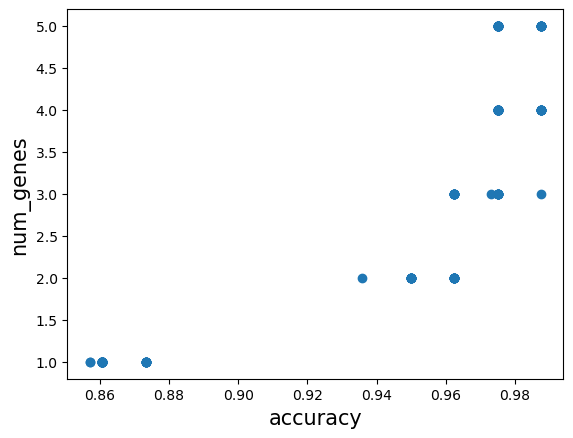

the best one is: accuracy is  0.9875 , num of genes is  3
selected genes are:  ['D83243_at' 'D88378_at' 'D88795_at']
the best one of generation 0 is: accuracy is  0.9232142857142858 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9339285714285713 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9339285714285713 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9339285714285713 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9482142857142858 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9607142857142857 , num of genes is  4
the best one of generation 6 is: accuracy is  0.975 , num of genes is  4
the best one of generation 7 is: accuracy is  0.975 , num of genes is  4
the best one of generation 8 is: accuracy is  0.975 , num of genes is  4
the best one of generation 9 is: accuracy is  0.975 , num of genes is  3
the best one of generation 10 is: accuracy is  0.975 , num of genes is  3
t

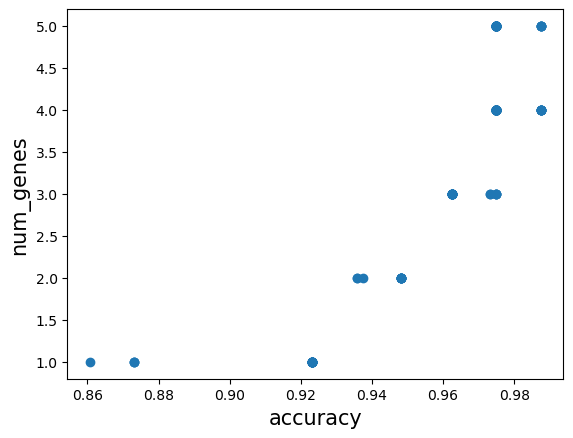

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D88378_at' 'D87433_at' 'D15050_at' 'AF015950_at']
the best one of generation 0 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 1 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 2 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 3 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 4 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 10 is: accuracy is  0.975 , num of genes is  5
the best one of generation 11 is: accuracy is  0.975 , 

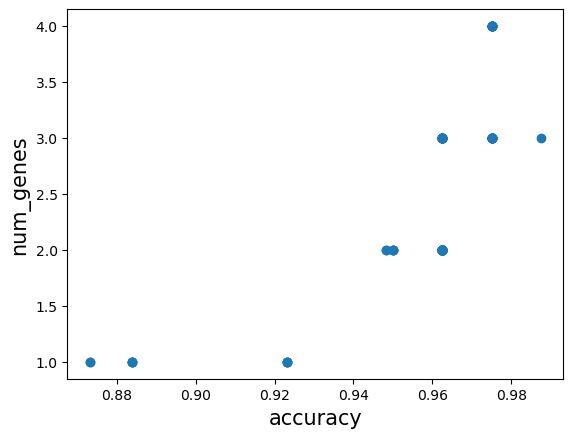

the best one is: accuracy is  0.9875 , num of genes is  3
selected genes are:  ['HG3995-HT4265_at' 'D79987_at' 'D86965_at']
the best one of generation 0 is: accuracy is  0.9125 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9125 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9357142857142857 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9357142857142857 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9357142857142857 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9482142857142858 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9482142857142858 , num of genes is  2
the best one of generation 7 is: accuracy is  0.95 , num of genes is  3
the best one of generation 8 is: accuracy is  0.95 , num of genes is  3
the best one of generation 9 is: accuracy is  0.95 , num of genes is  3
the best one of generation 10 is: accuracy is  0.95 , num of genes is  3
the best 

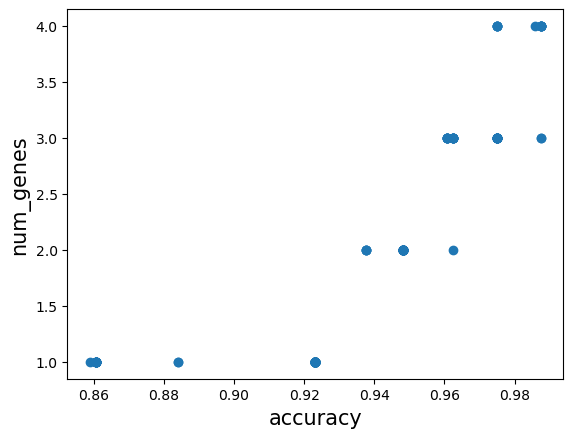

the best one is: accuracy is  0.9875 , num of genes is  3
selected genes are:  ['D26561_cds3_at' 'AF000560_at' 'D80011_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9357142857142857 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9625 , num of genes is  4
the best one of generatio

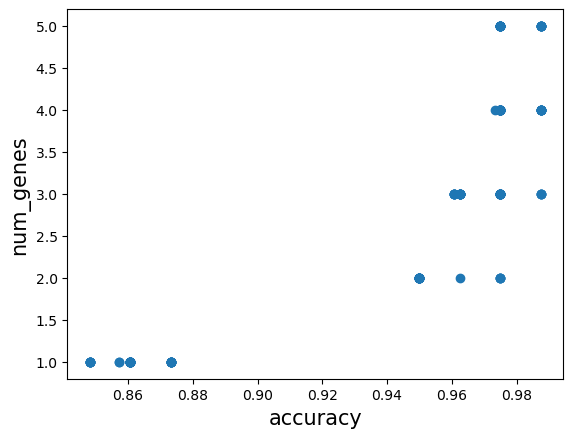

the best one is: accuracy is  0.9875 , num of genes is  3
selected genes are:  ['D87458_at' 'AF005037_at' 'D43948_at']
the best one of generation 0 is: accuracy is  0.9339285714285716 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9339285714285716 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9339285714285716 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9339285714285716 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9339285714285716 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9482142857142858 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9482142857142858 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9607142857142857 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9607142857142857 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9732142857142858 , num of genes is  4
the best one of gener

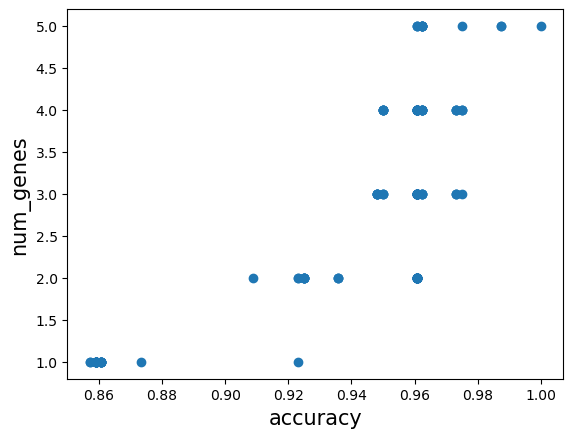

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['D44466_at' 'D15050_at' 'D79987_at' 'AF015950_at' 'D87447_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 1 is: accuracy is  0.95 , num of genes is  5
the best one of generation 2 is: accuracy is  0.95 , num of genes is  5
the best one of generation 3 is: accuracy is  0.95 , num of genes is  5
the best one of generation 4 is: accuracy is  0.95 , num of genes is  5
the best one of generation 5 is: accuracy is  0.95 , num of genes is  4
the best one of generation 6 is: accuracy is  0.975 , num of genes is  3
the best one of generation 7 is: accuracy is  0.975 , num of genes is  3
the best one of generation 8 is: accuracy is  0.975 , num of genes is  3
the best one of generation 9 is: accuracy is  0.975 , num of genes is  3
the best one of generation 10 is: accuracy is  0.975 , num of genes is  3
the best one of generation 11 is: accuracy is  0

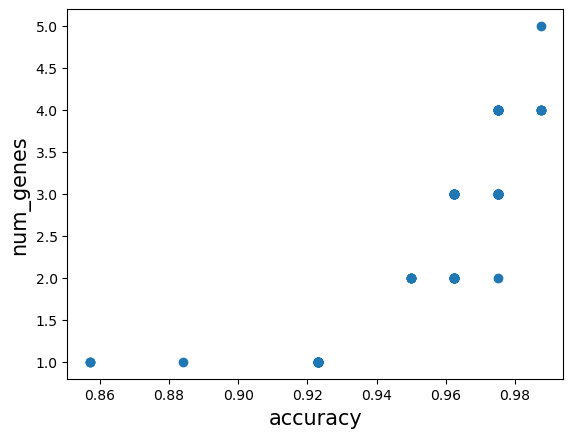

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['AF005037_at' 'D14661_at' 'D11428_at' 'D87433_at']
the best one of generation 0 is: accuracy is  0.875 , num of genes is  4
the best one of generation 1 is: accuracy is  0.875 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8982142857142857 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8982142857142857 , num of genes is  3
the best one of generation 4 is: accuracy is  0.925 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9482142857142858 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9482142857142858 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9482142857142858 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 9 is: accuracy is  0.975 , num of genes is  4
the best one of generation 10 is: accuracy is  0.975 , num of genes is  4

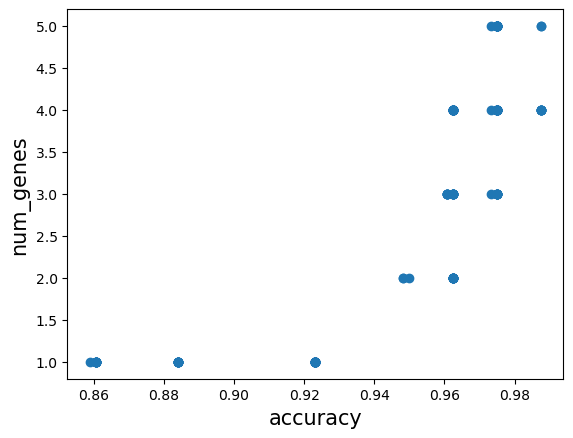

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D87433_at' 'HG172-HT3924_at' 'D78334_at' 'HG3994-HT4264_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 2 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9357142857142857 , num of genes is  

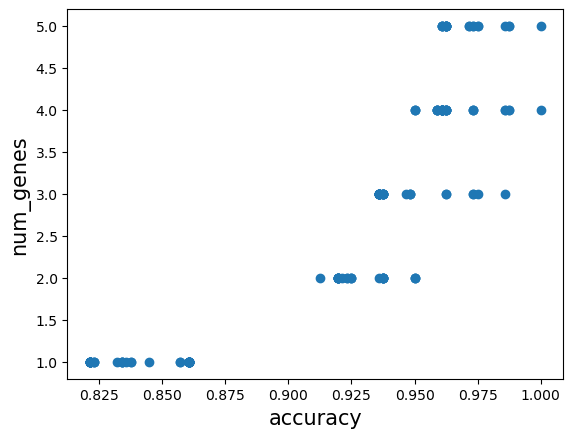

the best one is: accuracy is  1.0 , num of genes is  4
selected genes are:  ['D26561_cds3_at' 'AF007551_at' 'AF000177_at' 'D42041_at']
the best one of generation 0 is: accuracy is  0.925 , num of genes is  5
the best one of generation 1 is: accuracy is  0.925 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 10 is: accuracy is  0.9625 , num of genes is  5
the best one of generation 11 is: accuracy is  0.962

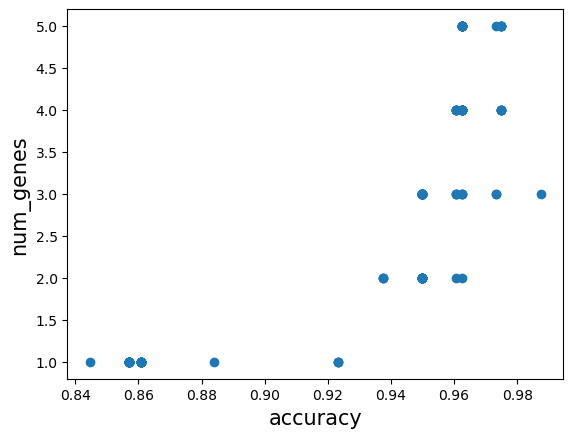

the best one is: accuracy is  0.9875 , num of genes is  3
selected genes are:  ['D16562_at' 'D14874_at' 'AF015950_at']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  3
the best one of generation 1 is: accuracy is  0.9196428571428571 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9196428571428571 , num of genes is  5
the best one of generation 3 is: accuracy is  0.975 , num of genes is  5
the best one of generation 4 is: accuracy is  0.975 , num of genes is  5
the best one of generation 5 is: accuracy is  0.975 , num of genes is  5
the best one of generation 6 is: accuracy is  0.975 , num of genes is  5
the best one of generation 7 is: accuracy is  0.975 , num of genes is  5
the best one of generation 8 is: accuracy is  0.975 , num of genes is  5
the best one of generation 9 is: accuracy is  0.975 , num of genes is  5
the best one of generation 10 is: accuracy is  0.975 , num of genes is  5
the best one of generation 11 is: accuracy is  0.9875

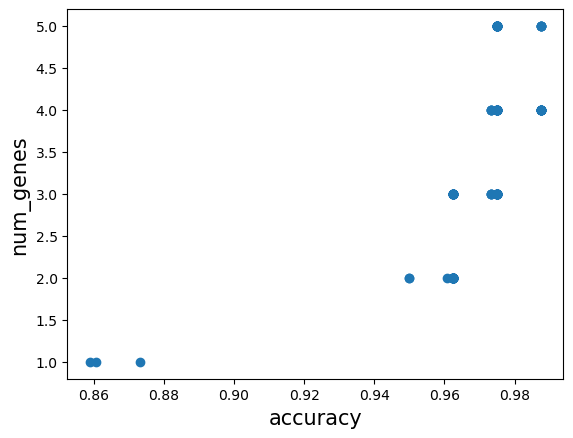

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D63878_at' 'D43948_at' 'D87077_at' 'AF001294_at']
the best one of generation 0 is: accuracy is  0.9071428571428571 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9107142857142858 , num of genes is  5
the best one of generation 2 is: accuracy is  0.95 , num of genes is  5
the best one of generation 3 is: accuracy is  0.95 , num of genes is  5
the best one of generation 4 is: accuracy is  0.95 , num of genes is  3
the best one of generation 5 is: accuracy is  0.95 , num of genes is  3
the best one of generation 6 is: accuracy is  0.95 , num of genes is  3
the best one of generation 7 is: accuracy is  0.95 , num of genes is  3
the best one of generation 8 is: accuracy is  0.95 , num of genes is  3
the best one of generation 9 is: accuracy is  0.95 , num of genes is  3
the best one of generation 10 is: accuracy is  0.95 , num of genes is  3
the best one of generation 11 is: accuracy is  0

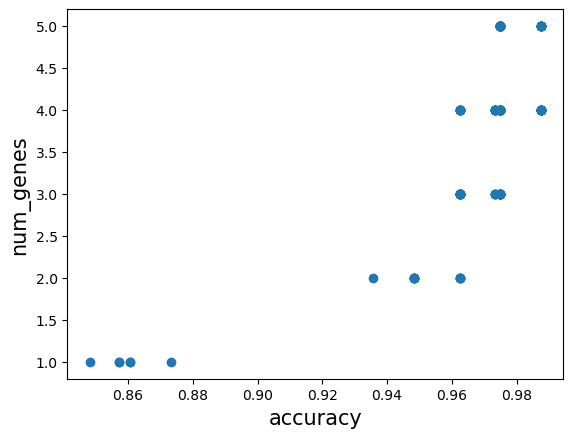

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['AF001294_at' 'HG2573-HT2669_at' 'D00591_at' 'AF003743_at']
the best one of generation 0 is: accuracy is  0.8964285714285716 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9107142857142858 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9107142857142858 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 4 is: accuracy is  0.95 , num of genes is  4
the best one of generation 5 is: accuracy is  0.95 , num of genes is  4
the best one of generation 6 is: accuracy is  0.95 , num of genes is  4
the best one of generation 7 is: accuracy is  0.95 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9875 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9875 , num of genes is  4
the best one of g

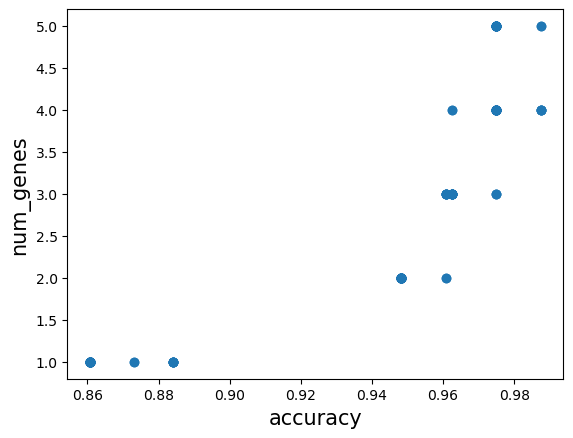

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D25278_at' 'D80006_at' 'AF005775_at' 'AF000560_at']
the best one of generation 0 is: accuracy is  0.8982142857142857 , num of genes is  3
the best one of generation 1 is: accuracy is  0.9232142857142858 , num of genes is  1
the best one of generation 2 is: accuracy is  0.9232142857142858 , num of genes is  1
the best one of generation 3 is: accuracy is  0.95 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9607142857142857 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9607142857142857 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 9 is: accuracy is  0.975 , num of genes is  5
the best one of generation 10 is: accuracy is  0.975 , num of genes is

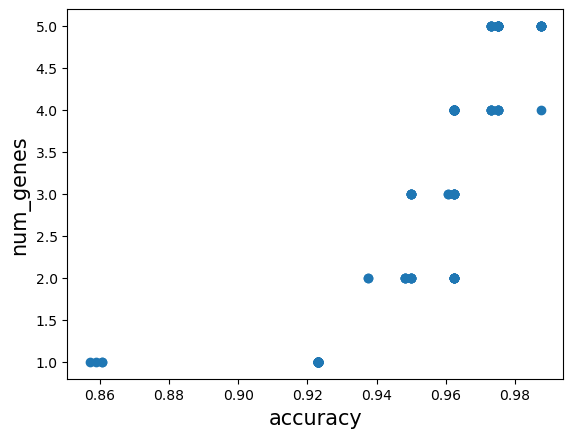

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['AF000560_at' 'AF005037_at' 'D87442_at' 'AF000545_at']
the best one of generation 0 is: accuracy is  0.9107142857142858 , num of genes is  2
the best one of generation 1 is: accuracy is  0.9107142857142858 , num of genes is  2
the best one of generation 2 is: accuracy is  0.9125 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9125 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9232142857142858 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9232142857142858 , num of genes is  5
the best one of generation 6 is: accuracy is  0.925 , num of genes is  4
the best one of generation 7 is: accuracy is  0.925 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9482142857142858 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9482142857142858 , num of genes is  4
the best one of generation 10 is: accuracy is  0.960714

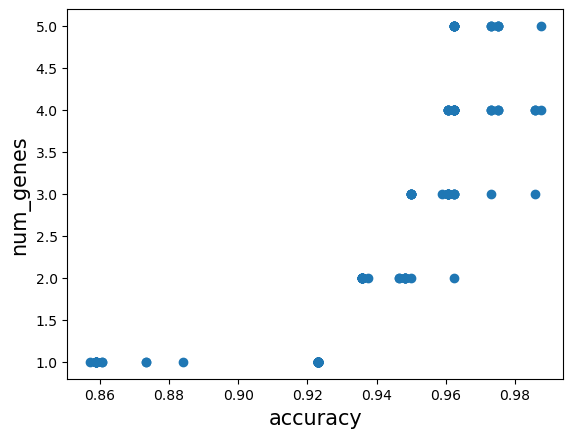

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D14658_at' 'D26561_cds3_at' 'D49818_at' 'D80006_at']
the best one of generation 0 is: accuracy is  0.9232142857142858 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9232142857142858 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9232142857142858 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9232142857142858 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9232142857142858 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9232142857142858 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9375 , num of genes is  3
the best one of generation 9 is: accuracy is  0.95 , num of genes is  2
the best one of generation 10 is

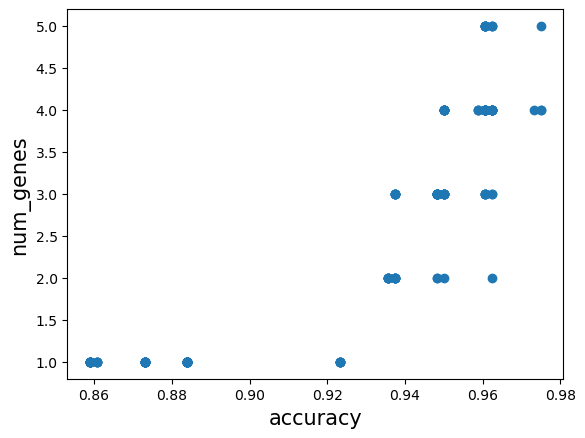

the best one is: accuracy is  0.975 , num of genes is  4
selected genes are:  ['AF005037_at' 'D30756_at' 'D83657_at' 'D26561_cds2_at']
the best one of generation 0 is: accuracy is  0.9107142857142858 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9107142857142858 , num of genes is  4
the best one of generation 2 is: accuracy is  0.925 , num of genes is  3
the best one of generation 3 is: accuracy is  0.925 , num of genes is  3
the best one of generation 4 is: accuracy is  0.95 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 9 is: accuracy is  1.0 , num of genes is  5
the best one of generation 10 is: accuracy is  1.0 , num of genes is  5
the best one of generation 11 is: ac

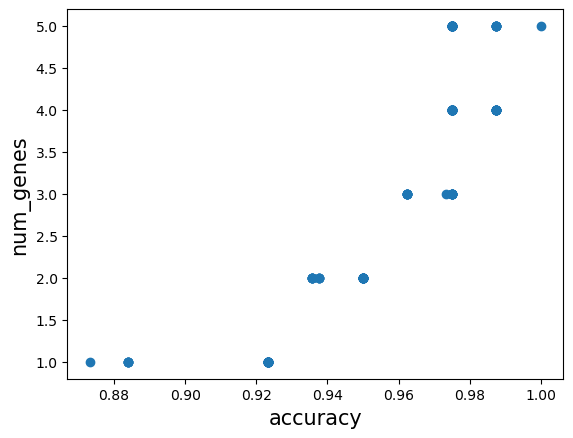

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['HG2290-HT2386_at' 'D80011_at' 'D79988_at' 'HG3286-HT3463_at'
 'AF014958_at']
the best one of generation 0 is: accuracy is  0.8982142857142857 , num of genes is  5
the best one of generation 1 is: accuracy is  0.925 , num of genes is  4
the best one of generation 2 is: accuracy is  0.925 , num of genes is  4
the best one of generation 3 is: accuracy is  0.925 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9357142857142857 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9607142857142857 , num of genes is  5
the best one of generati

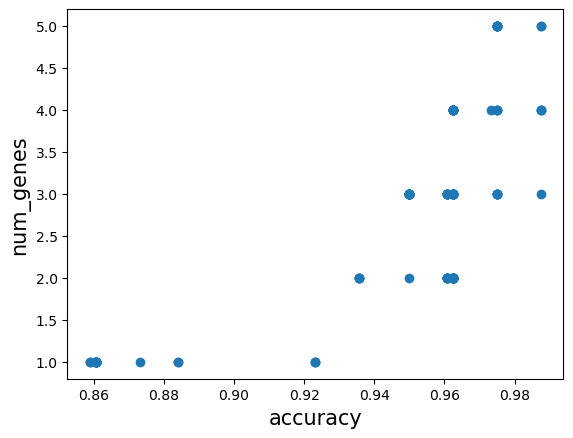

the best one is: accuracy is  0.9875 , num of genes is  3
selected genes are:  ['D15050_at' 'D79987_at' 'D87452_at']
the best one of generation 0 is: accuracy is  0.8982142857142857 , num of genes is  2
the best one of generation 1 is: accuracy is  0.8982142857142857 , num of genes is  2
the best one of generation 2 is: accuracy is  0.8982142857142857 , num of genes is  2
the best one of generation 3 is: accuracy is  0.9107142857142858 , num of genes is  2
the best one of generation 4 is: accuracy is  0.9232142857142858 , num of genes is  2
the best one of generation 5 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9375 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9732142857142858 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9732142857142858 , num

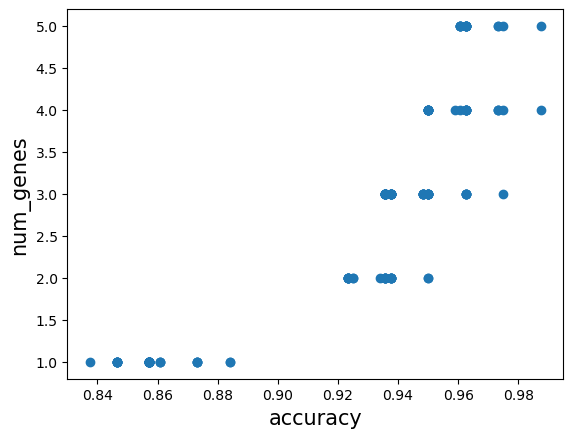

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D87433_at' 'D88152_at' 'D42041_at' 'AF015950_at']
the best one of generation 0 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9357142857142857 , num of genes is  5
the best one of generation 3 is: accuracy is  0.95 , num of genes is  4
the best one of generation 4 is: accuracy is  0.95 , num of genes is  4
the best one of generation 5 is: accuracy is  0.95 , num of genes is  4
the best one of generation 6 is: accuracy is  0.95 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9625 , num of genes is  3
the best one of generation

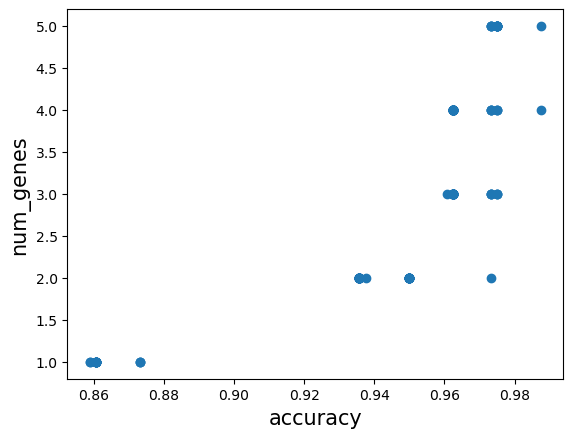

the best one is: accuracy is  0.9875 , num of genes is  4
selected genes are:  ['D38555_at' 'D83243_at' 'D14874_at' 'D23660_at']
the best one of generation 0 is: accuracy is  0.9125 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9125 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9375 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9375 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9375 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9375 , num of genes is  4
the best one of generation 6 is: accuracy is  0.95 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9625 , num of genes is  2
the best one of generation 10 is: accuracy is  0.975 , num of genes is  4
the best one of generation 11 is: accuracy is  0.975 , num 

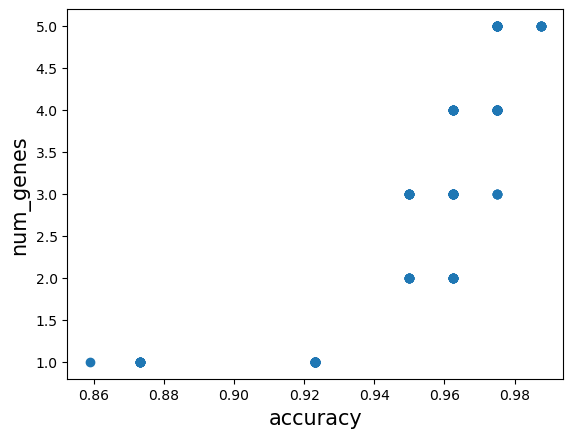

the best one is: accuracy is  0.9875 , num of genes is  5
selected genes are:  ['AF005037_at' 'D87023_cds2_at' 'D84307_at' 'D11086_at' 'D86479_at']


In [9]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
#df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=5,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1